## 1. Imports

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

from sklearn.model_selection import LeaveOneOut, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    roc_curve, accuracy_score, classification_report
)

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## 2. Configuration

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FOLDER   = '/content/drive/MyDrive/TA_Project/dataset/data'
METADATA_FILE = '/content/drive/MyDrive/TA_Project/dataset/dyslexia_class_label.csv'

# All 3 available tasks
ALL_TASKS = [
    'T1_Syllables',
    'T4_Meaningful',
    'T5_Pseudo_Text',
]

# Short prefix per task for column naming
TASK_LABELS = {t: t.split('_')[0] for t in ALL_TASKS}
# -> {'T1_Syllables': 'T1', 'T4_Meaningful': 'T4', 'T5_Pseudo_Text': 'T5'}

SAMPLING_RATE          = 250
FIXATION_MIN_MS        = 60
FIXATION_MAX_DISP      = 1
SACCADE_MIN_VEL        = 15
REGRESSION_THRESHOLD   = 0
REGRESSION_MAX_AMP_DEG = 2.5

SCREEN_WIDTH_CM  = 47.0
SCREEN_WIDTH_PX  = 1680
VIEWING_DIST_CM  = 60

PX_PER_DEG = (SCREEN_WIDTH_PX / SCREEN_WIDTH_CM) * (
    VIEWING_DIST_CM * np.tan(np.deg2rad(1)))

# The 9 proven optimal features from v2/v3
CORE_FEATURES = [
    'fix_cx_std', 'gaze_x_range', 'regr_count', 'sacc_pv_mean',
    'fix_disp_std', 'prog_amp_mean', 'vel_q95', 'fix_dur_q25', 'vel_median'
]

print(f'PX_PER_DEG : {PX_PER_DEG:.2f}')
print(f'Tasks      : {ALL_TASKS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PX_PER_DEG : 37.44
Tasks      : ['T1_Syllables', 'T4_Meaningful', 'T5_Pseudo_Text']


## 2b. Filename Verification
**Run this first** to confirm task names match your actual files before loading everything.

In [6]:
files = os.listdir(DATA_FOLDER)
print(f'Total files in data folder: {len(files)}\n')

for task in ALL_TASKS:
    matches = [f for f in files if task in f and 'raw.csv' in f]
    print(f'{task}: {len(matches)} files found')
    if matches:
        print(f'  Example: {matches[0]}')
    else:
        print(f'  *** WARNING: No files found — check task name spelling ***')

print('\nSample filenames:')
for f in sorted(files)[:10]:
    print(f'  {f}')

Total files in data folder: 839

T1_Syllables: 70 files found
  Example: Subject_1189_T1_Syllables_raw.csv
T4_Meaningful: 70 files found
  Example: Subject_1263_T4_Meaningful_Text_raw.csv
T5_Pseudo_Text: 70 files found
  Example: Subject_1038_T5_Pseudo_Text_raw.csv

Sample filenames:
  Subject_1003_T1_Syllables_fixations.csv
  Subject_1003_T1_Syllables_metrics.csv
  Subject_1003_T1_Syllables_raw.csv
  Subject_1003_T1_Syllables_saccades.csv
  Subject_1003_T4_Meaningful_Text_fixations.csv
  Subject_1003_T4_Meaningful_Text_metrics.csv
  Subject_1003_T4_Meaningful_Text_raw.csv
  Subject_1003_T4_Meaningful_Text_saccades.csv
  Subject_1003_T5_Pseudo_Text_fixations.csv
  Subject_1003_T5_Pseudo_Text_metrics.csv


## 3. Data Loading — All 3 Tasks

In [7]:
def load_raw_subject(filepath):
    with open(filepath, 'r') as f:
        first_line = f.readline()
    sep = ';' if ';' in first_line else ','
    df = pd.read_csv(filepath, sep=sep, low_memory=False)
    for col in df.columns:
        if df[col].dtype == object:
            try:
                df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
            except (ValueError, AttributeError):
                pass

    def find_col(*kws):
        for col in df.columns:
            if all(k.lower() in col.lower() for k in kws):
                return col
        return None

    lx = find_col('gaze_x_left')  or find_col('left', 'x')
    rx = find_col('gaze_x_right') or find_col('right', 'x')
    ly = find_col('gaze_y_left')  or find_col('left', 'y')
    ry = find_col('gaze_y_right') or find_col('right', 'y')
    ts = find_col('timestamp')    or find_col('time')

    if not (lx and rx and ly and ry):
        raise ValueError(f'Gaze columns not found in: {filepath}')

    result = pd.DataFrame({
        'gaze_x_left' : df[lx].astype(float),
        'gaze_x_right': df[rx].astype(float),
        'gaze_y_left' : df[ly].astype(float),
        'gaze_y_right': df[ry].astype(float),
    })
    result['avg_x'] = (result['gaze_x_left']  + result['gaze_x_right']) / 2
    result['avg_y'] = (result['gaze_y_left']  + result['gaze_y_right']) / 2
    result['timestamp'] = (
        df[ts].astype(float) if ts
        else np.arange(len(result)) * (1000.0 / SAMPLING_RATE)
    )
    return result


def load_all_tasks():
    print('Loading metadata...')
    meta = pd.read_csv(METADATA_FILE, sep=',')
    meta['subject_id'] = meta['subject_id'].astype(str)
    labels_all = dict(zip(meta['subject_id'], meta['class_id']))

    files = os.listdir(DATA_FOLDER)
    task_dfs = {t: {} for t in ALL_TASKS}

    for filename in files:
        for task in ALL_TASKS:
            if task in filename and 'raw.csv' in filename:
                subj_id = filename.split('_')[1]
                if subj_id not in labels_all:
                    continue
                try:
                    df = load_raw_subject(os.path.join(DATA_FOLDER, filename))
                    if len(df.dropna()) > 50:
                        task_dfs[task][subj_id] = df
                except Exception:
                    pass

    # Only keep subjects present in ALL 3 tasks
    sets = [set(task_dfs[t].keys()) for t in ALL_TASKS]
    all_subjs = sets[0]
    for s in sets[1:]:
        all_subjs = all_subjs & s

    labels = {s: labels_all[s] for s in all_subjs}

    print(f'Subjects in ALL 3 tasks : {len(all_subjs)}')
    print(f'Class distribution      : {pd.Series(labels).value_counts().to_dict()}')
    for task in ALL_TASKS:
        print(f'  {task:<22}: {len(task_dfs[task])} total files loaded')

    return task_dfs, labels, sorted(list(all_subjs))


task_dfs, labels, subject_list = load_all_tasks()

Loading metadata...
Subjects in ALL 3 tasks : 70
Class distribution      : {1: 35, 0: 35}
  T1_Syllables          : 70 total files loaded
  T4_Meaningful         : 70 total files loaded
  T5_Pseudo_Text        : 70 total files loaded


## 4. Event Detection Functions

In [8]:
def compute_velocity_single(x, y):
    dt = 1.0 / SAMPLING_RATE
    dx = np.diff(x, prepend=x[0]) / PX_PER_DEG
    dy = np.diff(y, prepend=y[0]) / PX_PER_DEG
    vel = np.sqrt(dx**2 + dy**2) / dt
    valid = ~np.isnan(vel)
    if valid.sum() > 7:
        vel_interp = pd.Series(vel).interpolate(method='linear').bfill().ffill().values
        vel_smooth = savgol_filter(vel_interp, window_length=7, polyorder=2)
        vel_smooth[~valid] = np.nan
        return vel_smooth
    return vel


def detect_fixations_idt(x, y, ts):
    disp_px   = FIXATION_MAX_DISP * PX_PER_DEG
    min_samps = int((FIXATION_MIN_MS / 1000.0) * SAMPLING_RATE)
    fixations, n, i = [], len(x), 0
    while i < n:
        if np.isnan(x[i]) or np.isnan(y[i]):
            i += 1; continue
        ws = i
        j  = min(i + min_samps, n)
        wx = x[ws:j]; wy = y[ws:j]
        valid = ~(np.isnan(wx) | np.isnan(wy))
        if valid.sum() < max(2, min_samps // 2):
            i += 1; continue
        if (np.nanmax(wx)-np.nanmin(wx)) + (np.nanmax(wy)-np.nanmin(wy)) > disp_px:
            i += 1; continue
        while j < n:
            if np.isnan(x[j]) or np.isnan(y[j]): break
            nd = (np.nanmax(x[ws:j+1])-np.nanmin(x[ws:j+1]) +
                  np.nanmax(y[ws:j+1])-np.nanmin(y[ws:j+1]))
            if nd > disp_px: break
            j += 1
        dur = ts[j-1] - ts[ws] if j > ws else 0
        if dur >= FIXATION_MIN_MS:
            sx = x[ws:j]; sy = y[ws:j]
            fixations.append({
                'duration_ms'  : dur,
                'centroid_x'   : np.nanmean(sx),
                'centroid_y'   : np.nanmean(sy),
                'dispersion_px': np.nanmax(sx)-np.nanmin(sx)+np.nanmax(sy)-np.nanmin(sy),
            })
        i = j
    return fixations


def detect_saccades_ivt(x, y, ts):
    vel  = compute_velocity_single(x, y)
    is_s = (vel > SACCADE_MIN_VEL) & ~np.isnan(vel)
    saccades, in_s, start = [], False, 0
    for i in range(len(is_s)):
        if is_s[i] and not in_s:
            in_s = True; start = i
        elif not is_s[i] and in_s:
            in_s = False; end = i - 1
            if end >= start and not (np.isnan(x[end]) or np.isnan(x[start])):
                dx_  = x[end] - x[start]
                dy_  = y[end] - y[start]
                amp  = np.sqrt((dx_/PX_PER_DEG)**2 + (dy_/PX_PER_DEG)**2)
                saccades.append({
                    'duration_ms'   : ts[end] - ts[start],
                    'amplitude_deg' : amp,
                    'peak_velocity' : np.nanmax(vel[start:end+1]),
                    'dx_px'         : dx_,
                    'is_regression' : (dx_ < REGRESSION_THRESHOLD
                                       and amp < REGRESSION_MAX_AMP_DEG),
                })
    return saccades


print('Event detection functions defined.')

Event detection functions defined.


## 5. Per-Task Feature Extraction

In [9]:
def extract_subject_features(df):
    ts       = np.arange(len(df)) * (1000.0 / SAMPLING_RATE)
    total_ms = ts[-1] - ts[0] if len(ts) > 1 else 0
    eps      = 1e-6
    eye_feats = []

    for xcol, ycol in [('gaze_x_left','gaze_y_left'),
                        ('gaze_x_right','gaze_y_right')]:
        ex = pd.Series(df[xcol].values).rolling(5, min_periods=1, center=True).median().values
        ey = pd.Series(df[ycol].values).rolling(5, min_periods=1, center=True).median().values
        valid = ~(np.isnan(ex) | np.isnan(ey))
        if valid.sum() < 50: continue

        vel       = compute_velocity_single(ex, ey)
        vel_clean = vel[valid & (vel < 3000)]
        fix = detect_fixations_idt(ex, ey, ts)
        sac = detect_saccades_ivt(ex, ey, ts)
        n_fix = len(fix); n_sacc = len(sac)
        ef = {}

        if n_fix > 0:
            fd = [f['duration_ms']   for f in fix]
            fp = [f['dispersion_px'] for f in fix]
            fx = [f['centroid_x']    for f in fix]
            fy = [f['centroid_y']    for f in fix]
            ef.update({
                'fix_count'    : n_fix,
                'fix_dur_mean' : np.mean(fd), 'fix_dur_std' : np.std(fd),
                'fix_dur_q25'  : np.percentile(fd, 25),
                'fix_dur_q75'  : np.percentile(fd, 75),
                'fix_disp_mean': np.mean(fp), 'fix_disp_std': np.std(fp),
                'fix_cx_std'   : np.std(fx),  'fix_cy_std'  : np.std(fy),
                'fix_time_prop': sum(fd) / total_ms if total_ms > 0 else 0,
            })
        else:
            for k in ['fix_count','fix_dur_mean','fix_dur_std','fix_dur_q25',
                      'fix_dur_q75','fix_disp_mean','fix_disp_std',
                      'fix_cx_std','fix_cy_std','fix_time_prop']:
                ef[k] = 0.0

        if n_sacc > 0:
            regr = [s for s in sac if s['is_regression']]
            prog = [s for s in sac if not s['is_regression']]
            nr   = len(regr)
            prog_amp = np.mean([p['amplitude_deg'] for p in prog]) if prog else 0.0
            ef.update({
                'sacc_count'     : n_sacc,
                'sacc_dur_mean'  : np.mean([s['duration_ms']   for s in sac]),
                'sacc_amp_mean'  : np.mean([s['amplitude_deg'] for s in sac]),
                'sacc_pv_mean'   : np.mean([s['peak_velocity'] for s in sac]),
                'sacc_pv_std'    : np.std( [s['peak_velocity'] for s in sac]),
                'regr_count'     : nr,
                'regr_proportion': nr / n_sacc,
                'regr_amp_mean'  : np.mean([abs(r['amplitude_deg']) for r in regr]) if nr > 0 else 0.0,
                'prog_amp_mean'  : prog_amp,
                'regr_prog_ratio': (np.mean([abs(r['amplitude_deg']) for r in regr]) / prog_amp
                                    if nr > 0 and prog_amp > 0 else 0.0),
            })
        else:
            for k in ['sacc_count','sacc_dur_mean','sacc_amp_mean','sacc_pv_mean',
                      'sacc_pv_std','regr_count','regr_proportion','regr_amp_mean',
                      'prog_amp_mean','regr_prog_ratio']:
                ef[k] = 0.0

        ef['vel_median']          = np.median(vel_clean) if len(vel_clean) > 0 else 0.0
        ef['vel_q95']             = np.percentile(vel_clean, 95) if len(vel_clean) > 0 else 0.0
        ef['vel_mean']            = np.mean(vel_clean) if len(vel_clean) > 0 else 0.0
        ef['gaze_x_range']        = np.nanmax(ex) - np.nanmin(ex)
        ef['gaze_y_range']        = np.nanmax(ey) - np.nanmin(ey)
        ef['regr_per_fixation']   = ef['regr_count'] / (ef['fix_count'] + eps)
        ef['spatial_instability'] = ef['fix_cx_std'] / (ef['gaze_x_range'] + eps)
        eye_feats.append(ef)

    if not eye_feats: return None
    merged = {k: np.mean([ef[k] for ef in eye_feats]) for k in eye_feats[0]}

    # ── Reading fatigue features (from v3) ────────────────────────────────────
    n_samp = len(df)
    third  = max(n_samp // 3, 10)
    rates  = []
    dur_thirds = []
    for start, end in [(0, third), (third, 2*third), (2*third, n_samp)]:
        chunk = df.iloc[start:end]
        cx = pd.Series(chunk['avg_x'].values).rolling(5, center=True).median().values
        valid_cx = cx[~np.isnan(cx)]
        if len(valid_cx) < 10:
            rates.append(0.0)
            dur_thirds.append(0.0)
            continue
        dx_ = np.diff(valid_cx)
        rates.append((dx_ < -5).sum() / (len(dx_) + 1e-6))
        # fixation duration per third (left eye only, fast)
        ts_c = np.arange(len(chunk)) * (1000.0 / SAMPLING_RATE)
        ex_c = pd.Series(chunk['gaze_x_left'].values).rolling(5, min_periods=1, center=True).median().values
        ey_c = pd.Series(chunk['gaze_y_left'].values).rolling(5, min_periods=1, center=True).median().values
        fix_c = detect_fixations_idt(ex_c, ey_c, ts_c)
        dur_thirds.append(np.mean([f['duration_ms'] for f in fix_c]) if fix_c else 0.0)

    merged['fatigue_regr_slope']    = rates[2] - rates[0]        # positive = worsens over time
    merged['fatigue_regr_slope_mid']= rates[1] - rates[0]        # early slope
    merged['fatigue_regr_max_third']= max(rates) if rates else 0.0
    merged['fatigue_fix_dur_drift'] = dur_thirds[2] - dur_thirds[0]  # fixations get longer = harder

    return merged


print('Feature extraction function defined.')

Feature extraction function defined.


In [10]:
 from tqdm.notebook import tqdm

print('Extracting features from all 3 tasks...\n')
task_features = {task: {} for task in ALL_TASKS}

for task in ALL_TASKS:
    for subj_id in tqdm(subject_list, desc=task, leave=True):
        df = task_dfs[task].get(subj_id)
        if df is None: continue
        feats = extract_subject_features(df)
        if feats is not None:
            task_features[task][subj_id] = feats
    print(f'  {task}: {len(task_features[task])}/{len(subject_list)} subjects OK')

valid_subjs = [s for s in subject_list
               if all(s in task_features[t] for t in ALL_TASKS)]
print(f'\nComplete subjects (all 3 tasks): {len(valid_subjs)}')

eps = 1e-6

def compute_ratio_features(fv):
    rf = {}
    rf['regr_per_fixation']   = fv.get('regr_count', 0)    / (fv.get('fix_count', 0) + eps)
    rf['spatial_instability'] = fv.get('fix_cx_std', 0)    / (fv.get('gaze_x_range', 0) + eps)
    rf['vel_fix_interaction']  = fv.get('vel_q95', 0)       *  fv.get('fix_dur_q25', 0)
    rf['regr_vs_prog_amp']    = fv.get('regr_amp_mean', 0)  / (fv.get('prog_amp_mean', 0) + eps)
    rf['main_seq_index']      = fv.get('sacc_pv_mean', 0)   / (fv.get('sacc_amp_mean', 0) + eps)
    rf['fix_disp_cv']         = fv.get('fix_disp_std', 0)   / (fv.get('fix_disp_mean', 0) + eps)
    return rf

BASE_FEATURES = [
    'fix_cx_std', 'gaze_x_range', 'regr_count', 'sacc_pv_mean',
    'fix_disp_std', 'prog_amp_mean', 'vel_q95', 'fix_dur_q25', 'vel_median',
]
RATIO_FEATURES = [
    'regr_per_fixation', 'spatial_instability', 'vel_fix_interaction',
    'regr_vs_prog_amp', 'main_seq_index', 'fix_disp_cv',
]
FATIGUE_FEATURES = [
    'fatigue_regr_slope', 'fatigue_regr_slope_mid',
    'fatigue_regr_max_third', 'fatigue_fix_dur_drift',
]

rows = []
y_labels = []

for subj_id in valid_subjs:
    row = {'subject_id': subj_id}
    tv  = {t: task_features[t][subj_id] for t in ALL_TASKS}

    # 1. Per-task base + ratio features (15 x 3 = 45)
    task_ratio_cache = {}
    for task in ALL_TASKS:
        pfx    = TASK_LABELS[task]
        fv     = tv[task]
        ratios = compute_ratio_features(fv)
        task_ratio_cache[task] = ratios
        for fname in BASE_FEATURES:
            row[f'{pfx}_{fname}'] = fv.get(fname, 0.0)
        for rname, rval in ratios.items():
            row[f'{pfx}_{rname}'] = rval

    # 2. Cross-task ratio deltas (T4 = easy baseline)
    r4 = task_ratio_cache['T4_Meaningful']
    r1 = task_ratio_cache['T1_Syllables']
    r5 = task_ratio_cache['T5_Pseudo_Text']
    for rname in RATIO_FEATURES:
        v4 = r4[rname]; v1 = r1[rname]; v5 = r5[rname]
        row[f'delta_{rname}_T1vsT4'] = v1 - v4
        row[f'delta_{rname}_T5vsT4'] = v5 - v4
        row[f'cross_{rname}_std']    = np.std([v1, v4, v5])

    # 3. Cross-task consistency on base features
    for fname in BASE_FEATURES:
        vals = [tv[t].get(fname, 0.0) for t in ALL_TASKS]
        row[f'cross_{fname}_std']  = np.std(vals)
        row[f'cross_{fname}_mean'] = np.mean(vals)

    # 4. Key aggregate cross-task signals
    regr_pf = [task_ratio_cache[t]['regr_per_fixation'] for t in ALL_TASKS]
    row['cross_regr_pf_slope_T1vsT4'] = regr_pf[0] - regr_pf[1]
    row['cross_regr_pf_slope_T5vsT4'] = regr_pf[2] - regr_pf[1]
    row['cross_regr_pf_max']          = max(regr_pf)
    row['cross_regr_pf_std']          = np.std(regr_pf)
    sp_vals = [task_ratio_cache[t]['spatial_instability'] for t in ALL_TASKS]
    row['cross_spatial_instab_slope'] = sp_vals[0] - sp_vals[1]
    row['cross_spatial_instab_max']   = max(sp_vals)

    # 5. Per-task fatigue features + cross-task fatigue deltas
    for fname in FATIGUE_FEATURES:
        vals = [tv[t].get(fname, 0.0) for t in ALL_TASKS]
        for task in ALL_TASKS:
            row[f'{TASK_LABELS[task]}_{fname}'] = tv[task].get(fname, 0.0)
        row[f'cross_{fname}_T1vsT4'] = tv['T1_Syllables'].get(fname, 0.0) - tv['T4_Meaningful'].get(fname, 0.0)
        row[f'cross_{fname}_max']    = max(vals)
        row[f'cross_{fname}_std']    = np.std(vals)

    rows.append(row)
    y_labels.append(int(labels[subj_id]))

df_multi = pd.DataFrame(rows)
y_multi  = np.array(y_labels)

per_task_cols = [c for c in df_multi.columns
                 if c.startswith('T1_') or c.startswith('T4_') or c.startswith('T5_')]
cross_cols    = [c for c in df_multi.columns
                 if c.startswith('cross_') or c.startswith('delta_')]
print(f'\nFeature matrix      : {df_multi.shape}')
print(f'Per-task features   : {len(per_task_cols)}')
print(f'Cross-task features : {len(cross_cols)}')
print(f'Class distribution  : {pd.Series(y_multi).value_counts().to_dict()}')

cors = {c: abs(df_multi[c].corr(pd.Series(y_multi)))
        for c in per_task_cols + cross_cols if not df_multi[c].isna().all()}
print('\nTop features by |correlation| with label:')
for c, v in sorted(cors.items(), key=lambda x: -x[1])[:12]:
    print(f'  {c:<50} |r|={v:.3f}')

Extracting features from all 3 tasks...



T1_Syllables:   0%|          | 0/70 [00:00<?, ?it/s]

  T1_Syllables: 70/70 subjects OK


T4_Meaningful:   0%|          | 0/70 [00:00<?, ?it/s]

  T4_Meaningful: 70/70 subjects OK


T5_Pseudo_Text:   0%|          | 0/70 [00:00<?, ?it/s]

  T5_Pseudo_Text: 70/70 subjects OK

Complete subjects (all 3 tasks): 70

Feature matrix      : (70, 112)
Per-task features   : 57
Cross-task features : 54
Class distribution  : {0: 35, 1: 35}

Top features by |correlation| with label:
  T4_regr_count                                      |r|=0.526
  cross_regr_count_mean                              |r|=0.512
  T5_regr_count                                      |r|=0.491
  cross_regr_count_std                               |r|=0.462
  T1_regr_count                                      |r|=0.449
  delta_fix_disp_cv_T5vsT4                           |r|=0.419
  delta_regr_vs_prog_amp_T5vsT4                      |r|=0.417
  cross_vel_q95_mean                                 |r|=0.379
  delta_vel_fix_interaction_T5vsT4                   |r|=0.375
  T4_vel_q95                                         |r|=0.362
  T1_vel_q95                                         |r|=0.359
  T4_vel_fix_interaction                             |r|=0.358


## 7. Visualization

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Feature Distribution By Label


VISUALIZATION 1: Feature Distributions by Task


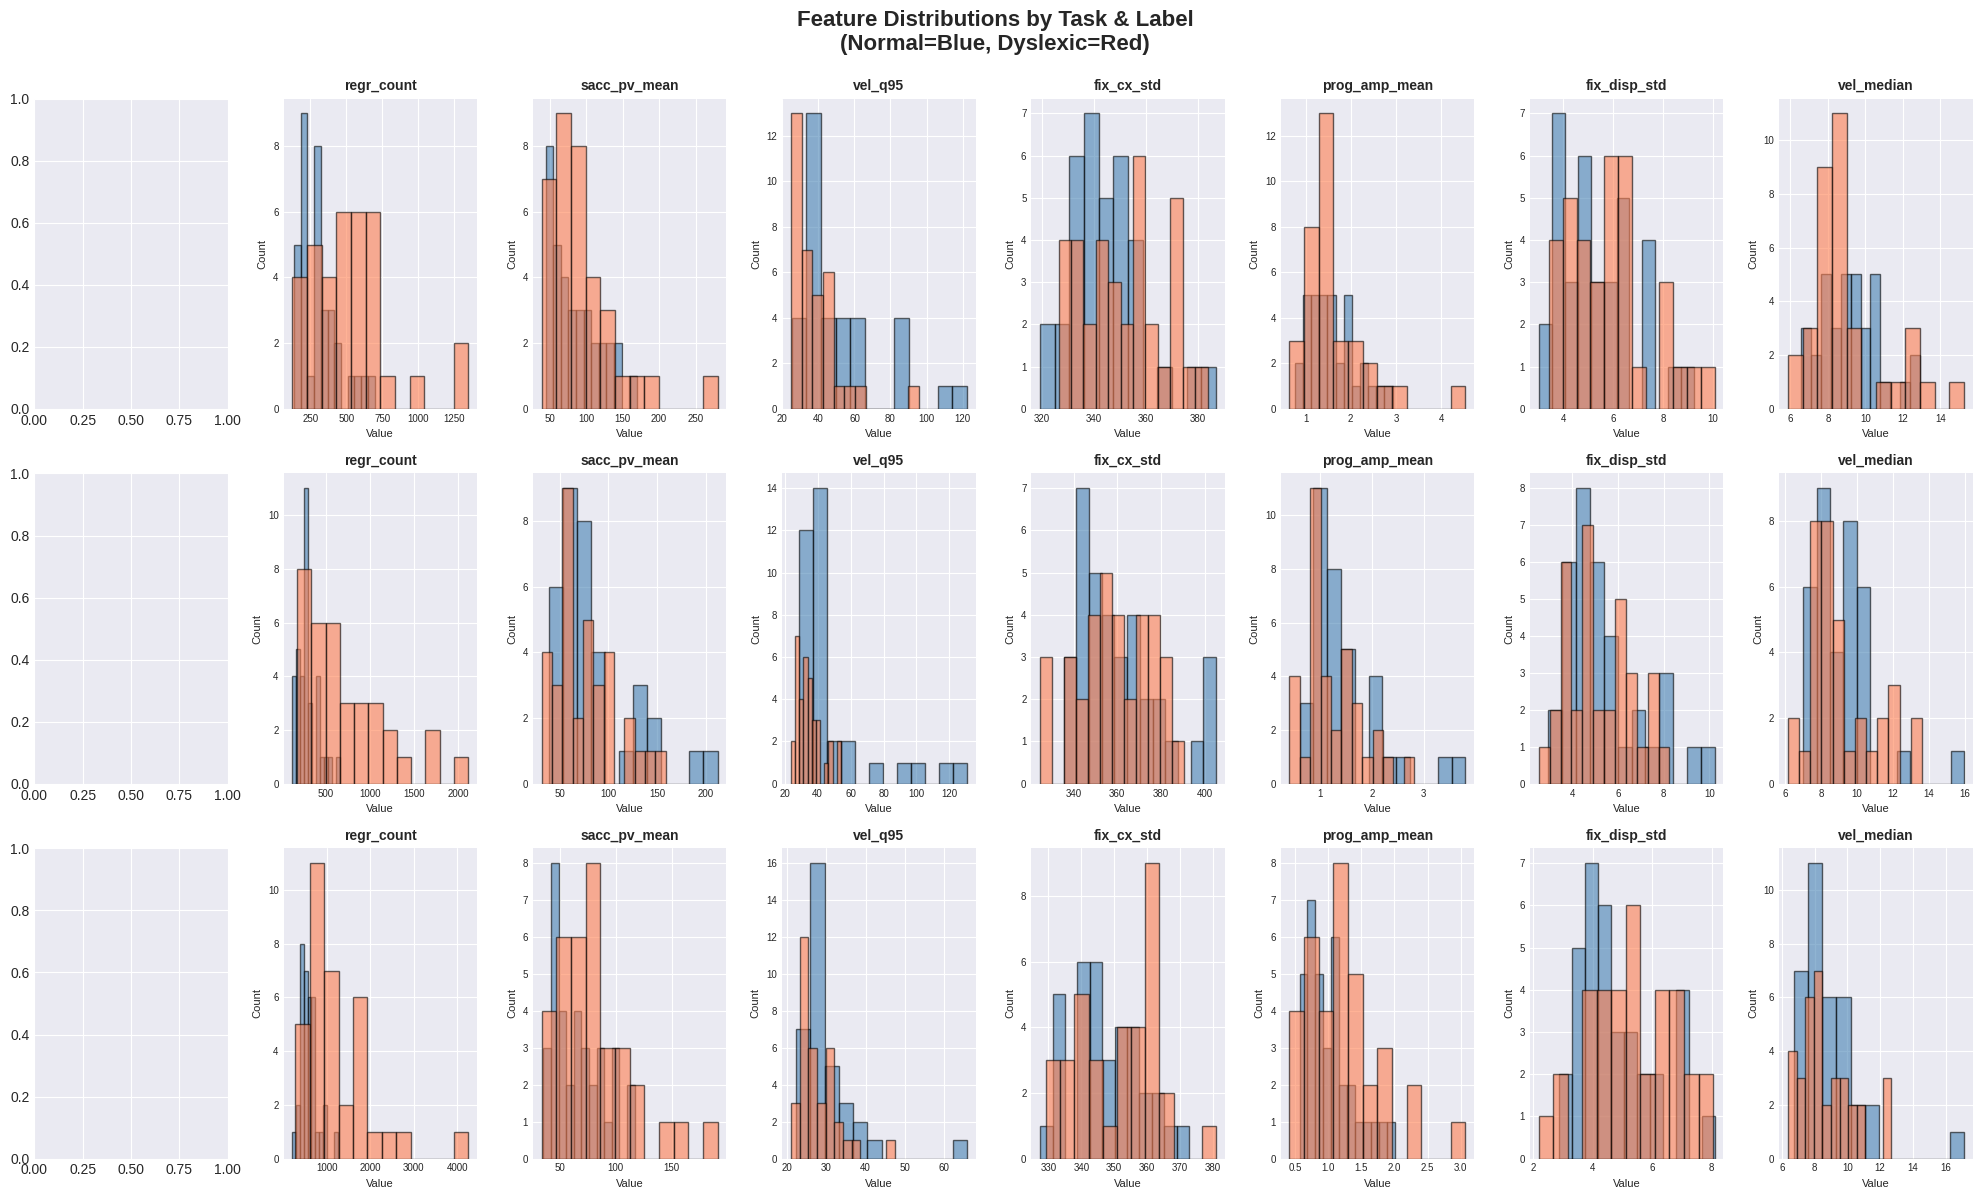

✓ Saved: Feature Distributions by Task


In [12]:
print("\n" + "="*70)
print("VISUALIZATION 1: Feature Distributions by Task")
print("="*70)

# Select key features to visualize
key_features_to_plot = [
    'fix_dur_mean', 'regr_count', 'sacc_pv_mean', 'vel_q95',
    'fix_cx_std', 'prog_amp_mean', 'fix_disp_std', 'vel_median'
]

fig, axes = plt.subplots(3, 8, figsize=(20, 12))
fig.suptitle('Feature Distributions by Task & Label\n(Normal=Blue, Dyslexic=Red)',
             fontsize=16, fontweight='bold', y=0.995)

for task_idx, task in enumerate(ALL_TASKS):
    task_label = TASK_LABELS[task]

    for feat_idx, feat in enumerate(key_features_to_plot):
        ax = axes[task_idx, feat_idx]

        # Extract feature for normal and dyslexic
        feat_col = f'{task_label}_{feat}'

        if feat_col in df_multi.columns:
            normal_data = df_multi[df_multi.index.map(lambda i: labels[valid_subjs[i]] == 0)][feat_col].dropna()
            dyslexic_data = df_multi[df_multi.index.map(lambda i: labels[valid_subjs[i]] == 1)][feat_col].dropna()

            # Plot distributions
            ax.hist(normal_data, bins=12, alpha=0.6, label='Normal', color='steelblue', edgecolor='black')
            ax.hist(dyslexic_data, bins=12, alpha=0.6, label='Dyslexic', color='coral', edgecolor='black')

            ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Value', fontsize=8)
            ax.set_ylabel('Count', fontsize=8)
            ax.tick_params(labelsize=7)

            if feat_idx == 0:
                ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/01_feature_distributions_by_task.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: Feature Distributions by Task")

### Box Plot


VISUALIZATION 2: Box Plots - Normal vs Dyslexic


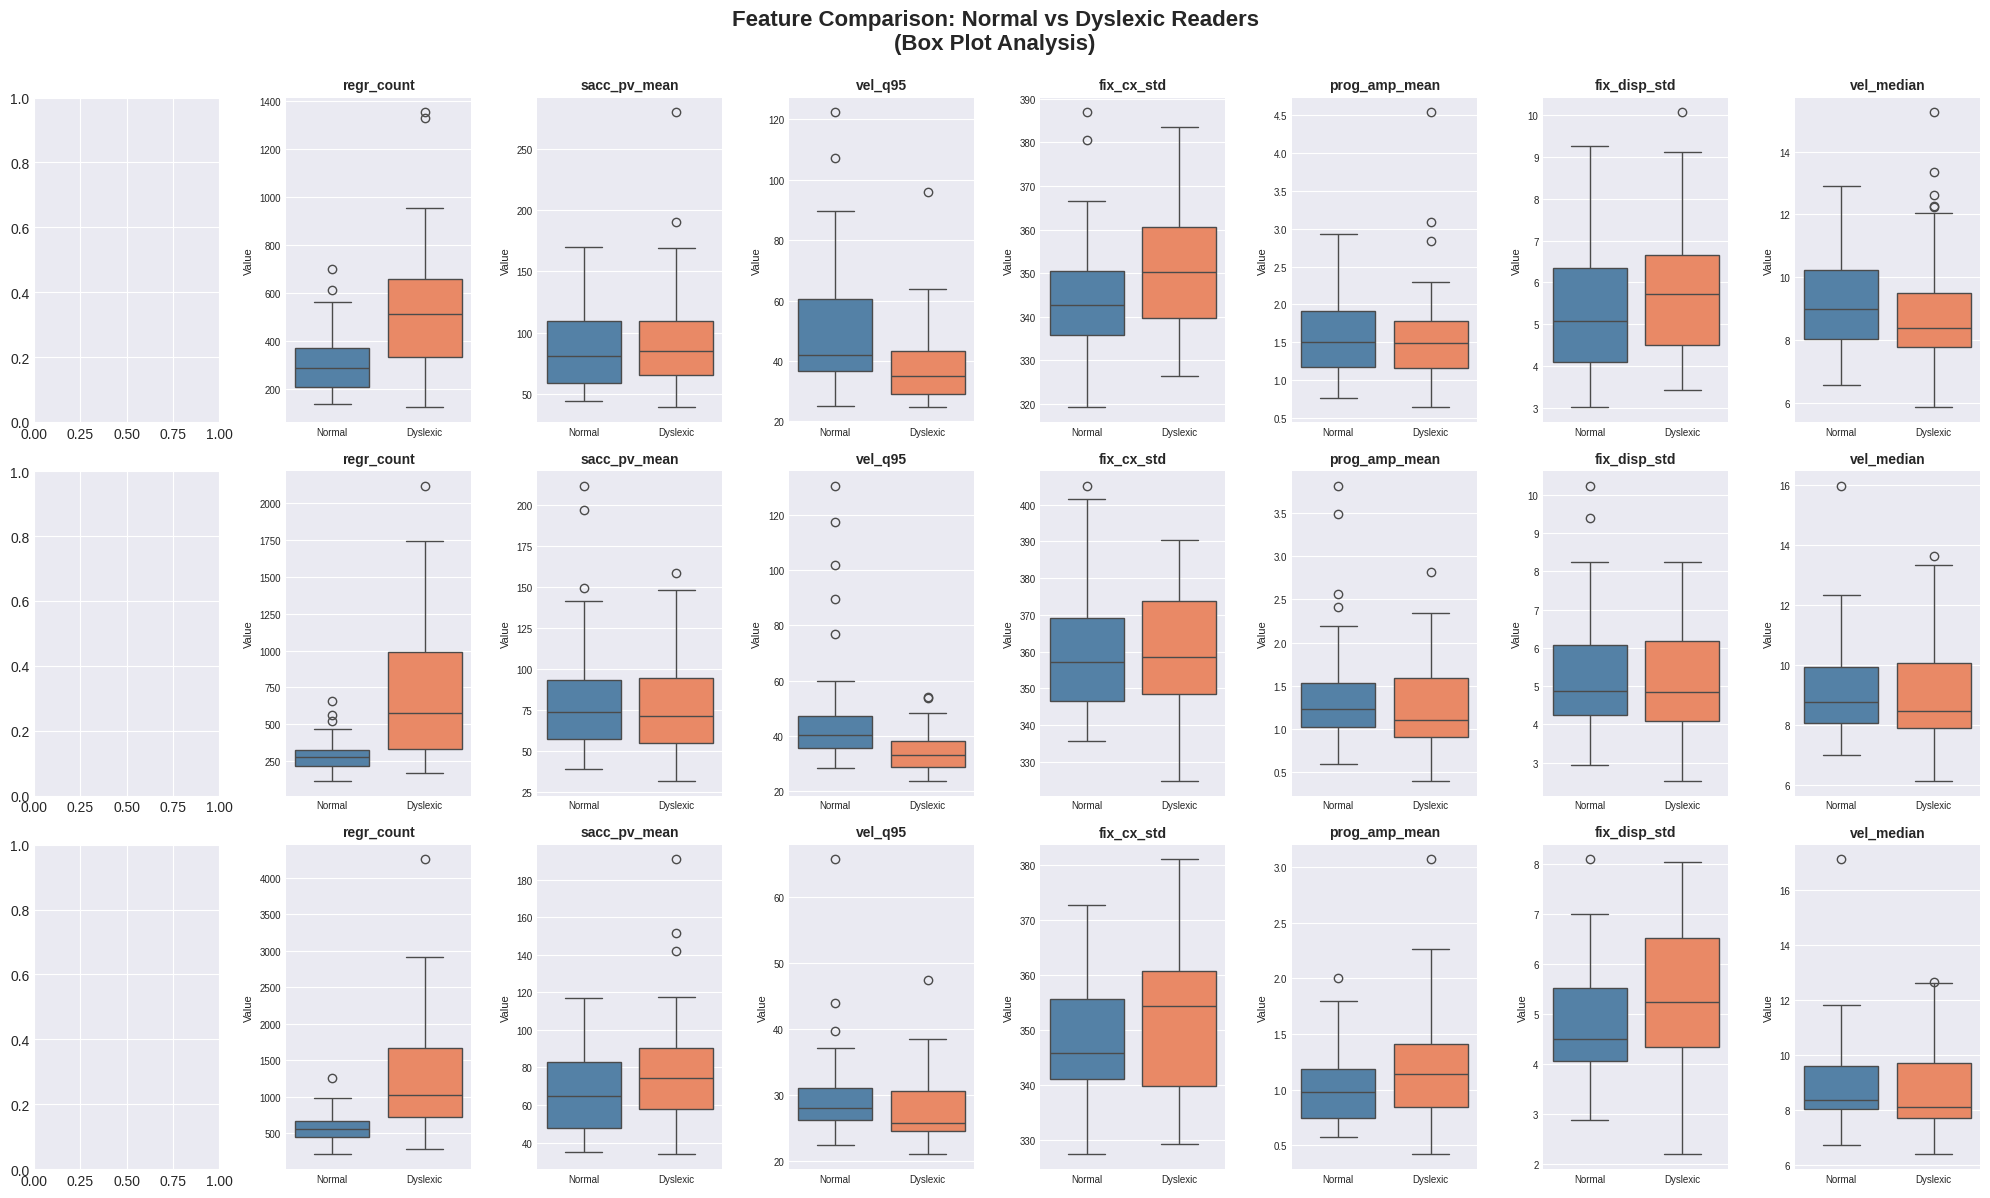

✓ Saved: Box Plot Comparison


In [13]:
print("\n" + "="*70)
print("VISUALIZATION 2: Box Plots - Normal vs Dyslexic")
print("="*70)

fig, axes = plt.subplots(3, 8, figsize=(20, 12))
fig.suptitle('Feature Comparison: Normal vs Dyslexic Readers\n(Box Plot Analysis)',
             fontsize=16, fontweight='bold', y=0.995)

for task_idx, task in enumerate(ALL_TASKS):
    task_label = TASK_LABELS[task]

    for feat_idx, feat in enumerate(key_features_to_plot):
        ax = axes[task_idx, feat_idx]

        feat_col = f'{task_label}_{feat}'

        if feat_col in df_multi.columns:
            # Create label column for this task
            data_to_plot = []
            labels_to_plot = []

            for i, subj_id in enumerate(valid_subjs):
                data_to_plot.append(df_multi.iloc[i][feat_col])
                labels_to_plot.append('Normal' if labels[subj_id] == 0 else 'Dyslexic')

            plot_df = pd.DataFrame({
                'Value': data_to_plot,
                'Group': labels_to_plot
            })

            # Box plot
            sns.boxplot(data=plot_df, x='Group', y='Value', ax=ax,
                       palette={'Normal': 'steelblue', 'Dyslexic': 'coral'})

            ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel('Value', fontsize=8)
            ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/02_boxplot_comparison.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: Box Plot Comparison")

### Correlation matrix

#### T1


VISUALIZATION 3: Correlation Matrix - T1_Syllables


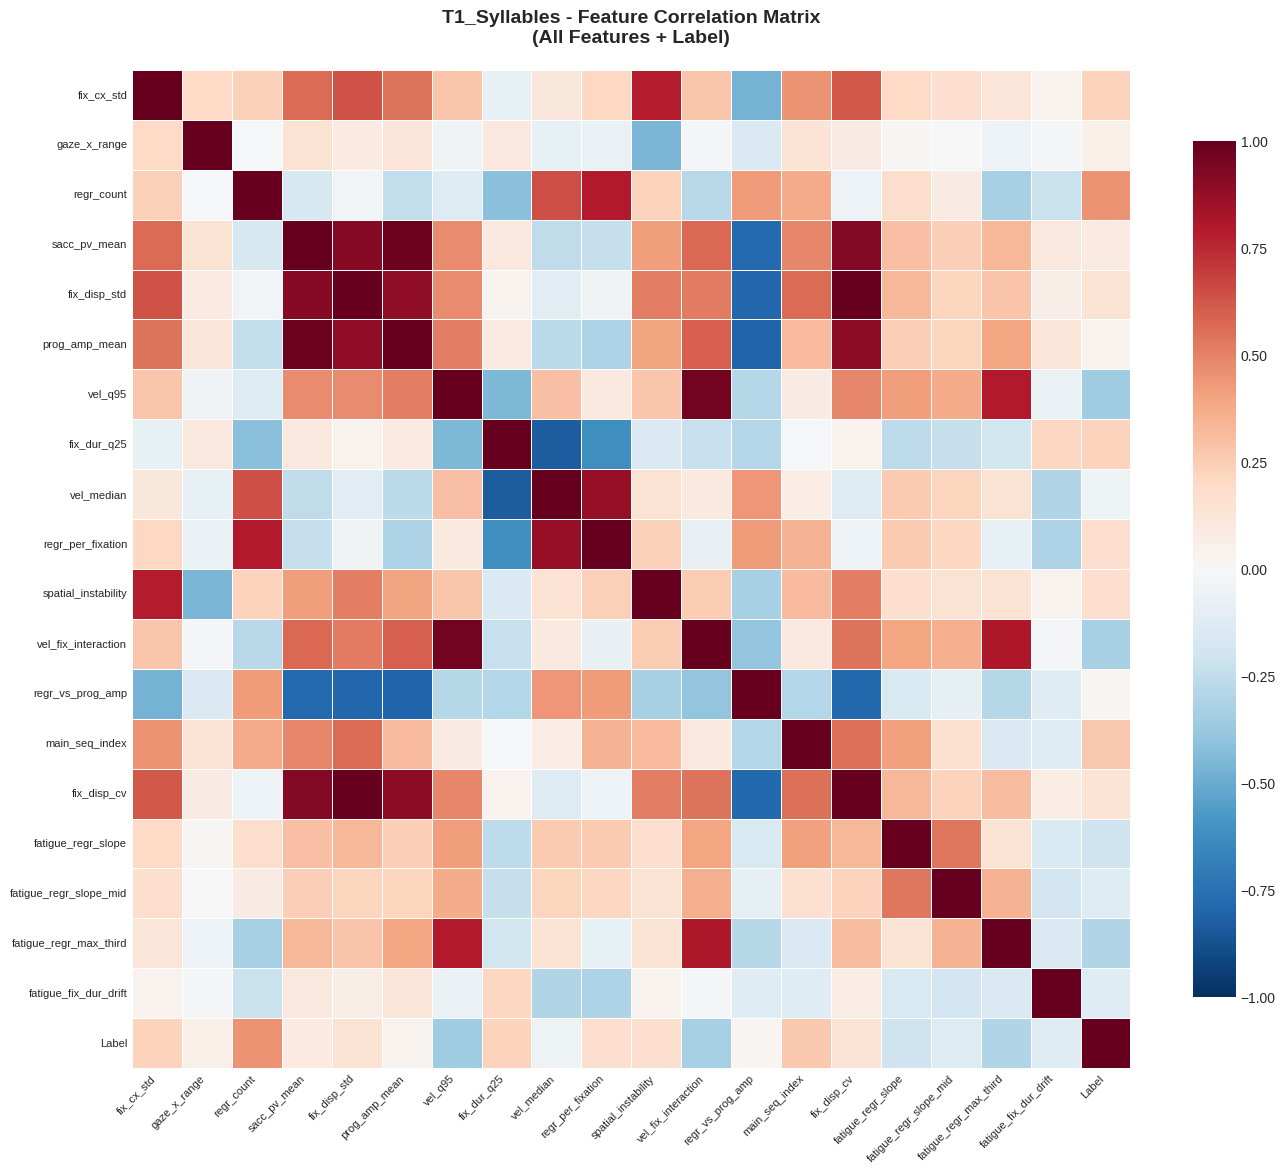

✓ Saved: T1 Correlation Matrix


In [14]:
print("\n" + "="*70)
print("VISUALIZATION 3: Correlation Matrix - T1_Syllables")
print("="*70)

# Get all T1 features
t1_features = [col for col in df_multi.columns if col.startswith('T1_') and col != 'subject_id']
t1_data = df_multi[t1_features].copy()
t1_data.columns = [col.replace('T1_', '') for col in t1_features]

# Add label
t1_data['Label'] = [labels[subj_id] for subj_id in valid_subjs]

# Calculate correlation
corr_t1 = t1_data.corr()

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_t1, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('T1_Syllables - Feature Correlation Matrix\n(All Features + Label)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/03_correlation_matrix_T1.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: T1 Correlation Matrix")


#### T4


VISUALIZATION 4: Correlation Matrix - T4_Meaningful


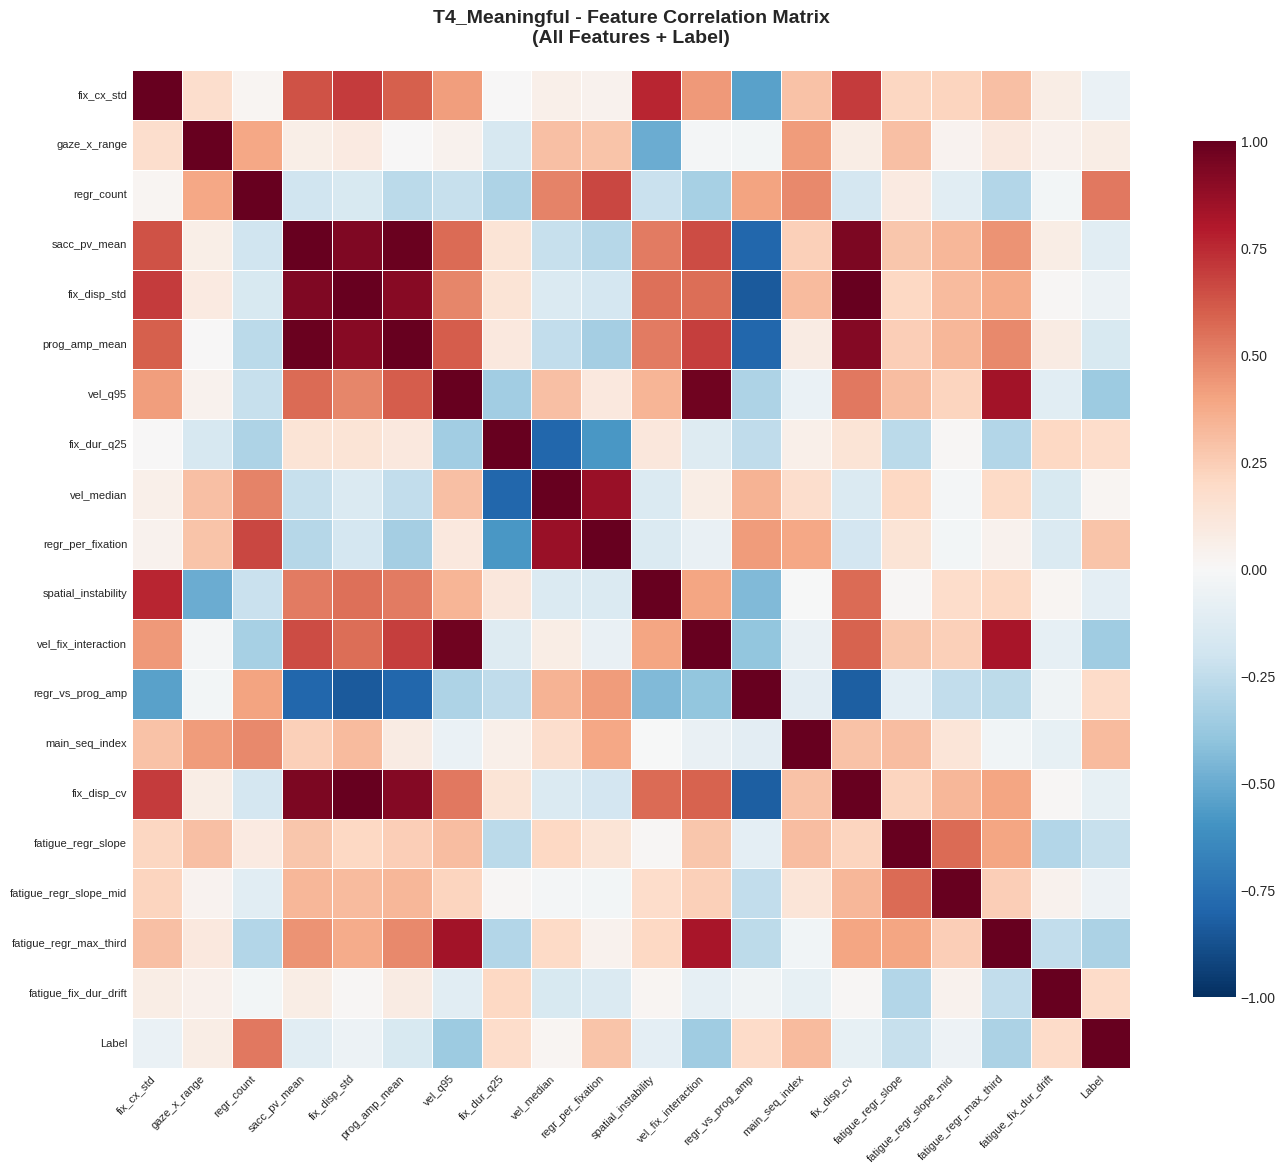

✓ Saved: T4 Correlation Matrix


In [15]:
print("\n" + "="*70)
print("VISUALIZATION 4: Correlation Matrix - T4_Meaningful")
print("="*70)

t4_features = [col for col in df_multi.columns if col.startswith('T4_') and col != 'subject_id']
t4_data = df_multi[t4_features].copy()
t4_data.columns = [col.replace('T4_', '') for col in t4_features]
t4_data['Label'] = [labels[subj_id] for subj_id in valid_subjs]

corr_t4 = t4_data.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_t4, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('T4_Meaningful - Feature Correlation Matrix\n(All Features + Label)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/04_correlation_matrix_T4.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: T4 Correlation Matrix")

#### T5


VISUALIZATION 5: Correlation Matrix - T5_Pseudo_Text


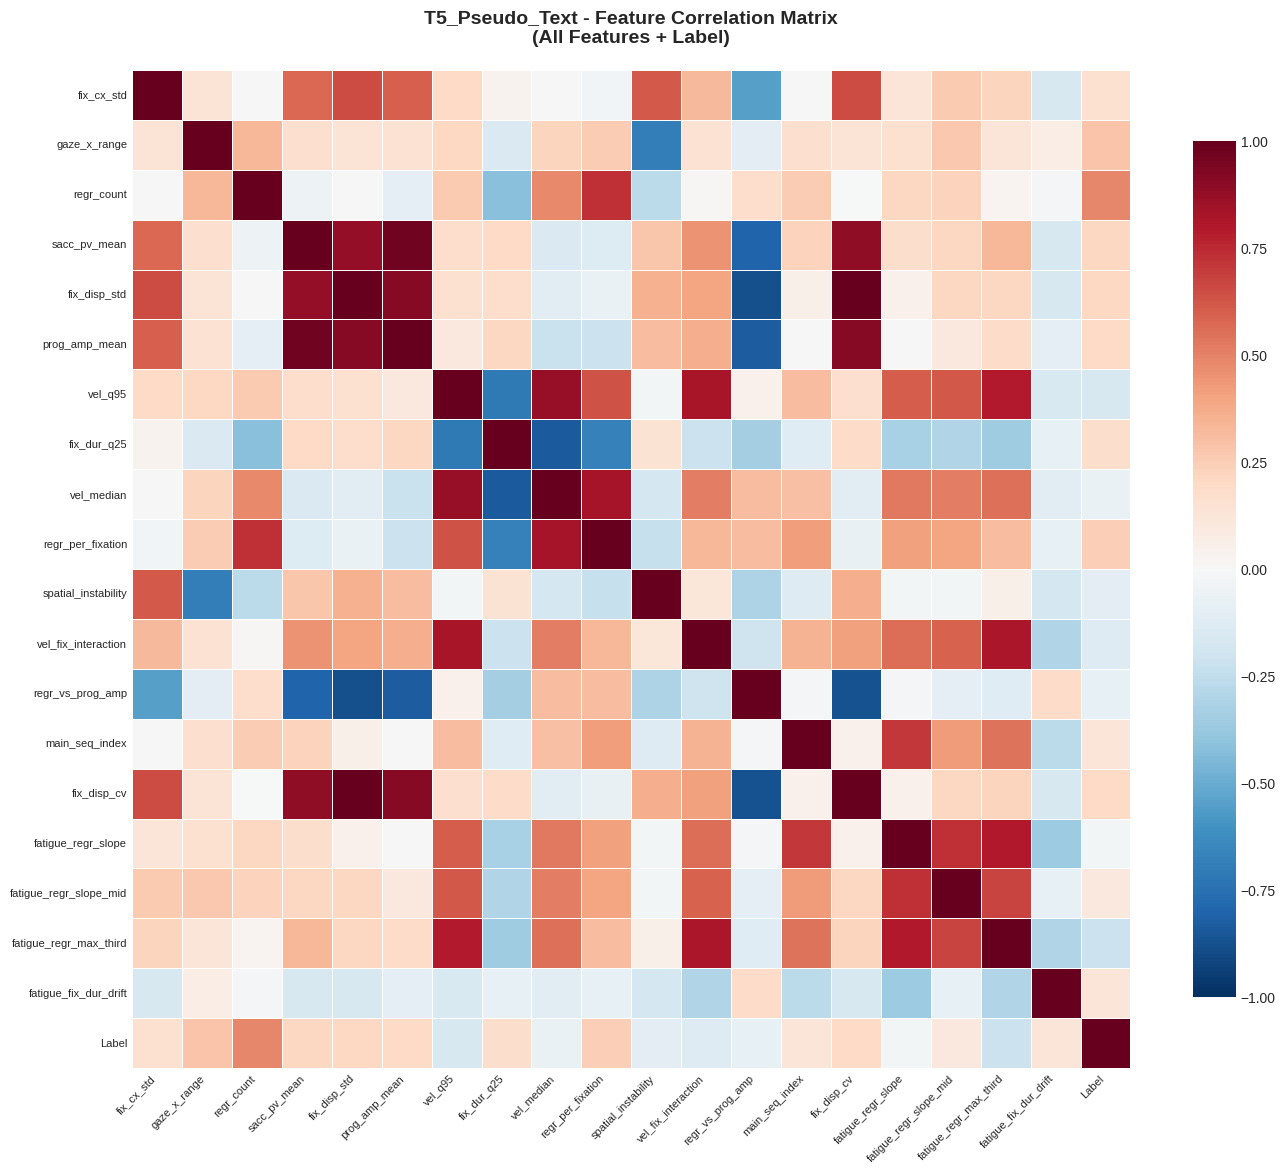

✓ Saved: T5 Correlation Matrix


In [16]:
print("\n" + "="*70)
print("VISUALIZATION 5: Correlation Matrix - T5_Pseudo_Text")
print("="*70)

t5_features = [col for col in df_multi.columns if col.startswith('T5_') and col != 'subject_id']
t5_data = df_multi[t5_features].copy()
t5_data.columns = [col.replace('T5_', '') for col in t5_features]
t5_data['Label'] = [labels[subj_id] for subj_id in valid_subjs]

corr_t5 = t5_data.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_t5, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('T5_Pseudo_Text - Feature Correlation Matrix\n(All Features + Label)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/05_correlation_matrix_T5.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: T5 Correlation Matrix")

#### Feature Importance correlation with label per task


VISUALIZATION 6: Feature Importance - Correlation with Label (per task)


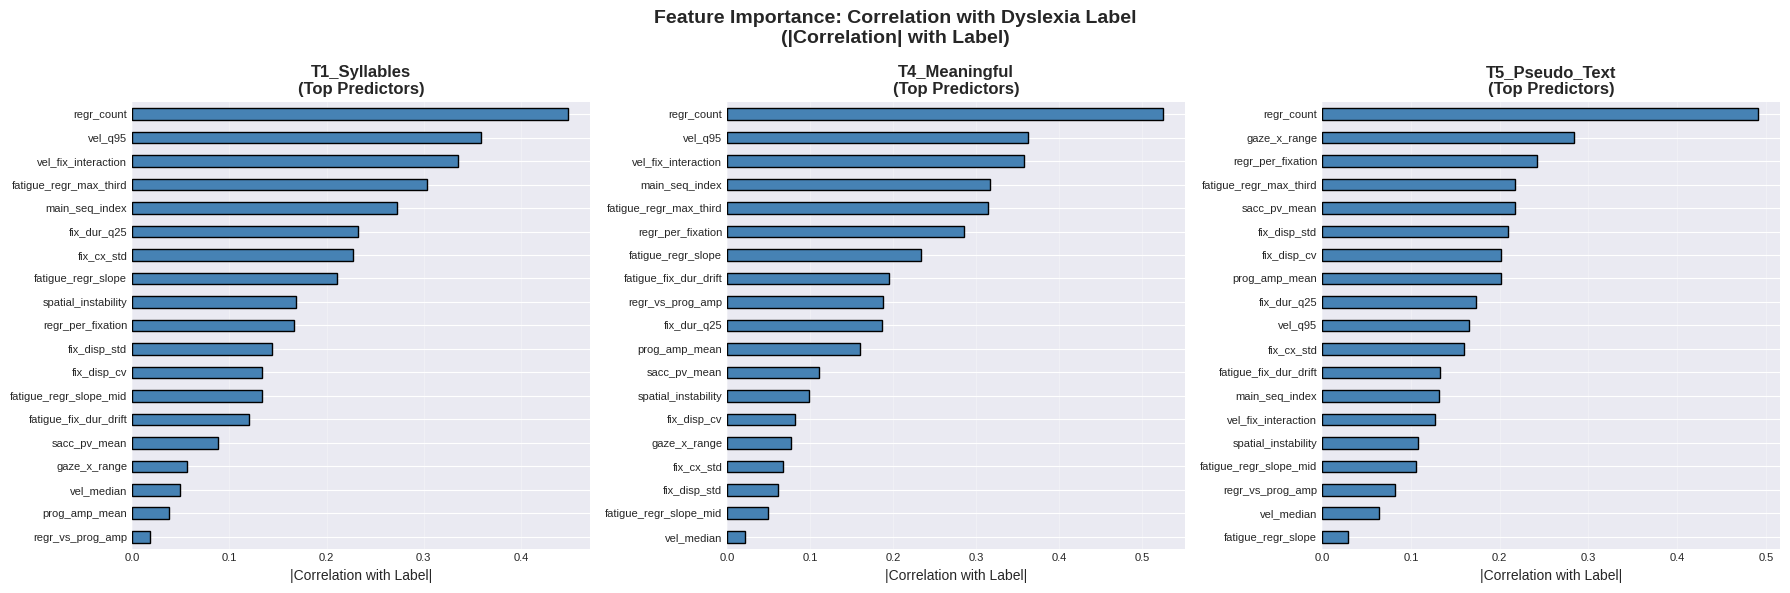

✓ Saved: Feature Importance per Task

VISUALIZATION 7: Top 15 Features - Correlation with Label (across tasks)


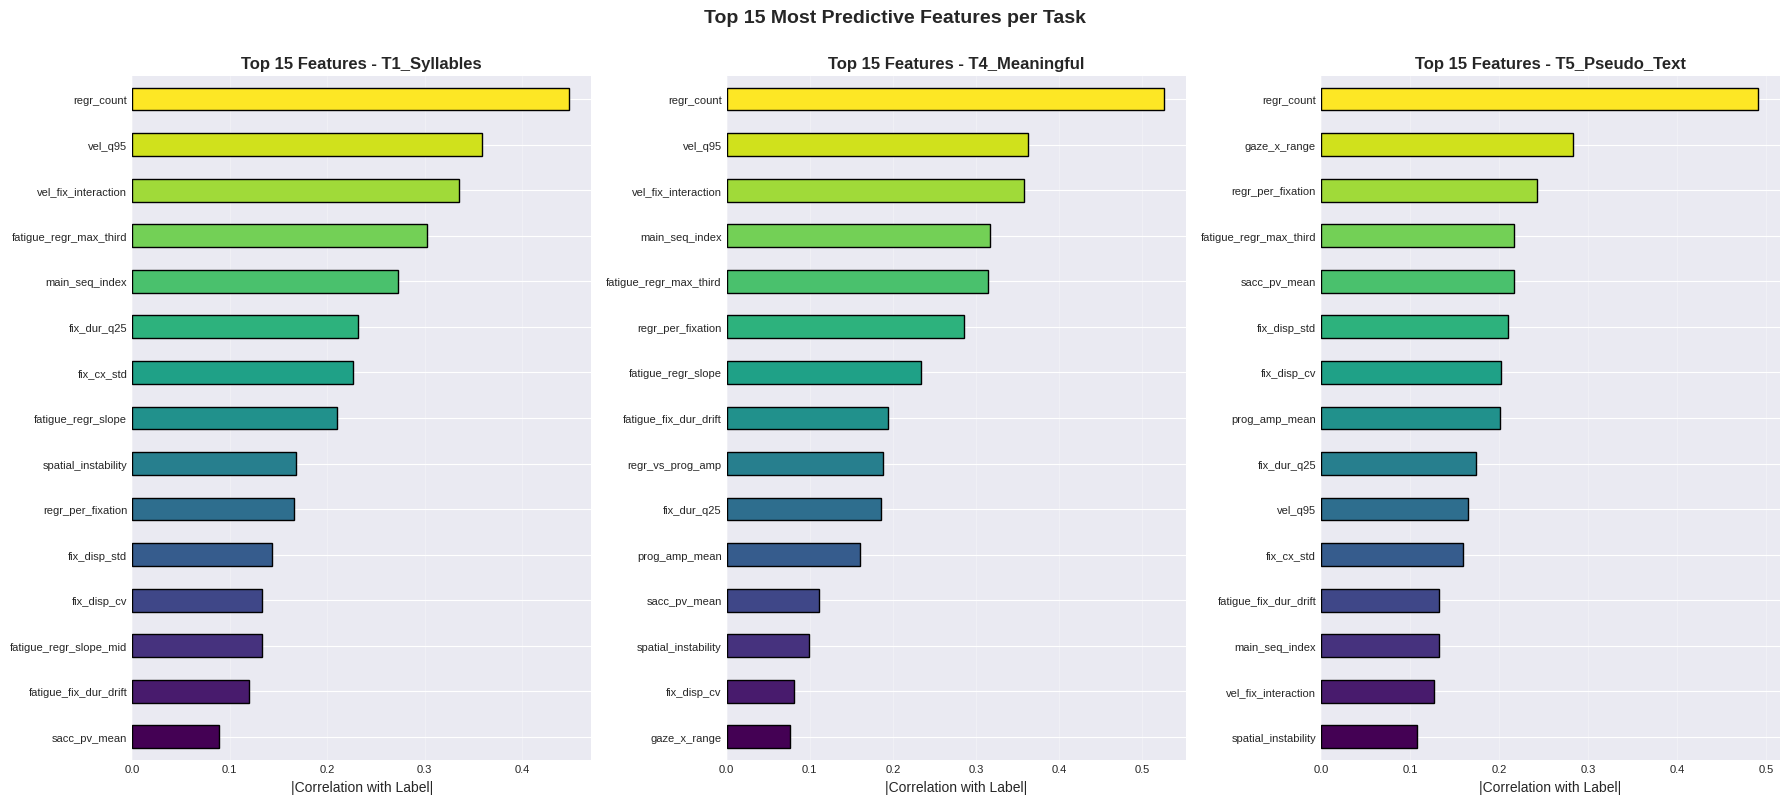

✓ Saved: Top 15 Features per Task


In [17]:
print("\n" + "="*70)
print("VISUALIZATION 6: Feature Importance - Correlation with Label (per task)")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance: Correlation with Dyslexia Label\n(|Correlation| with Label)',
             fontsize=14, fontweight='bold')

for task_idx, (task, corr_matrix, ax) in enumerate([
    ('T1_Syllables', corr_t1, axes[0]),
    ('T4_Meaningful', corr_t4, axes[1]),
    ('T5_Pseudo_Text', corr_t5, axes[2])
]):
    # Get correlation with label
    label_corr = corr_matrix['Label'].drop('Label').abs().sort_values(ascending=True)

    # Plot
    label_corr.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{task}\n(Top Predictors)', fontsize=12, fontweight='bold')
    ax.set_xlabel('|Correlation with Label|', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/06_feature_importance_per_task.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: Feature Importance per Task")

print("\n" + "="*70)
print("VISUALIZATION 7: Top 15 Features - Correlation with Label (across tasks)")
print("="*70)

# Get top features per task
top_t1 = corr_t1['Label'].drop('Label').abs().nlargest(15)
top_t4 = corr_t4['Label'].drop('Label').abs().nlargest(15)
top_t5 = corr_t5['Label'].drop('Label').abs().nlargest(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, (label, top_features, task_name) in zip(axes, [
    ('T1', top_t1, 'T1_Syllables'),
    ('T4', top_t4, 'T4_Meaningful'),
    ('T5', top_t5, 'T5_Pseudo_Text')
]):
    top_features.sort_values().plot(kind='barh', ax=ax,
                                    color=plt.cm.viridis(np.linspace(0, 1, 15)),
                                    edgecolor='black')
    ax.set_title(f'Top 15 Features - {task_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('|Correlation with Label|', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Top 15 Most Predictive Features per Task', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/07_top15_features_per_task.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: Top 15 Features per Task")

#### Important feature


VISUALIZATION 9: Top 2 Features - Scatter Plot per Task


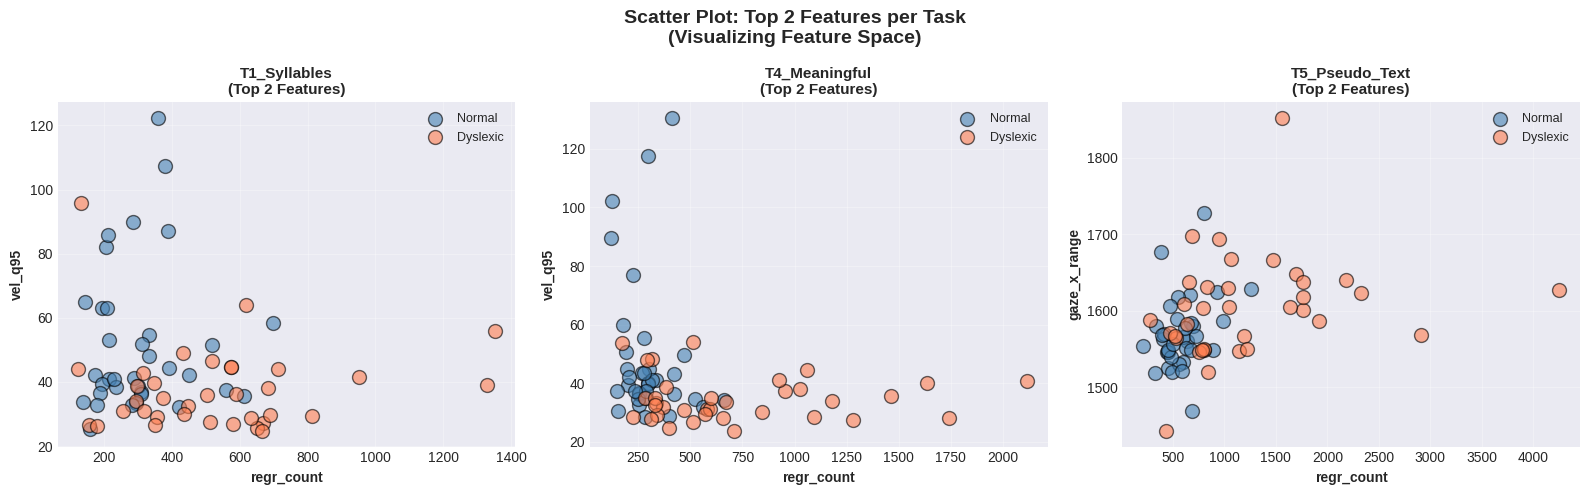

✓ Saved: Top 2 Features Scatter Plot


In [18]:
print("\n" + "="*70)
print("VISUALIZATION 9: Top 2 Features - Scatter Plot per Task")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (top_features, task_name, task_label) in zip(axes, [
    (top_t1, 'T1_Syllables', 'T1'),
    (top_t4, 'T4_Meaningful', 'T4'),
    (top_t5, 'T5_Pseudo_Text', 'T5')
]):
    # Get top 2 features
    feat1, feat2 = top_features.index[0], top_features.index[1]

    # Get data
    x = df_multi[f'{task_label}_{feat1}'].values
    y = df_multi[f'{task_label}_{feat2}'].values
    colors = [['steelblue', 'coral'][labels[subj_id]] for subj_id in valid_subjs]

    # Scatter plot
    for color, label in [('steelblue', 'Normal'), ('coral', 'Dyslexic')]:
        mask = np.array(colors) == color
        ax.scatter(x[mask], y[mask], c=color, label=label, s=100, alpha=0.6,
                  edgecolors='black', linewidth=1)

    ax.set_xlabel(f'{feat1}', fontsize=10, fontweight='bold')
    ax.set_ylabel(f'{feat2}', fontsize=10, fontweight='bold')
    ax.set_title(f'{task_name}\n(Top 2 Features)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Scatter Plot: Top 2 Features per Task\n(Visualizing Feature Space)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TA_Project/09_top2features_scatter.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: Top 2 Features Scatter Plot")

In [19]:
from sklearn.model_selection import cross_validate, LeaveOneOut, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [20]:
df_multi.describe()

,T1_fix_cx_std,T1_gaze_x_range,T1_regr_count,T1_sacc_pv_mean,T1_fix_disp_std,T1_prog_amp_mean,T1_vel_q95,T1_fix_dur_q25,T1_vel_median,T1_regr_per_fixation,...,T5_fatigue_regr_max_third,cross_fatigue_regr_max_third_T1vsT4,cross_fatigue_regr_max_third_max,cross_fatigue_regr_max_third_std,T1_fatigue_fix_dur_drift,T4_fatigue_fix_dur_drift,T5_fatigue_fix_dur_drift,cross_fatigue_fix_dur_drift_T1vsT4,cross_fatigue_fix_dur_drift_max,cross_fatigue_fix_dur_drift_std
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,347.825404,1552.221857,415.550000,90.461110,5.614459,1.597860,44.954421,88.450000,9.116534,0.701231,...,0.009572,0.001912,0.018468,0.003986,22.218191,10.996681,11.884622,11.221510,32.126692,14.593898
std,15.292940,47.025626,247.458607,40.850753,1.570120,0.638824,20.138101,10.443134,1.842103,0.175744,...,0.004743,0.004797,0.005263,0.001679,25.318491,20.361132,30.046305,26.456058,24.966928,9.149416
min,319.265513,1407.645000,123.500000,39.012144,3.021516,0.642002,24.712193,70.000000,5.869890,0.349858,...,0.005060,-0.017585,0.009949,0.000883,-47.997424,-34.847308,-51.780195,-43.867020,-14.257166,0.621003
25%,336.396358,1536.725000,230.250000,60.039972,4.423564,1.163656,32.600241,81.250000,7.906654,0.583434,...,0.006971,-0.000081,0.014579,0.002509,6.222796,-1.394259,-8.850507,-4.001663,15.796819,8.421181
50%,345.399814,1549.725000,347.000000,82.451360,5.423573,1.495116,38.921150,88.000000,8.730058,0.678910,...,0.008242,0.002437,0.018051,0.003984,21.661896,11.268171,11.406304,7.066950,28.645376,13.280957
75%,357.735879,1567.498750,569.375000,110.854276,6.517393,1.893260,48.810673,94.000000,9.999054,0.783215,...,0.009951,0.005446,0.021171,0.005080,34.321701,23.211129,30.002461,29.047933,45.075675,18.989550
max,386.879802,1672.910000,1351.500000,280.067520,10.060918,4.539721,122.370171,124.500000,15.251667,1.130638,...,0.032520,0.010603,0.037568,0.008881,101.622360,70.569006,103.625439,82.727790,103.625439,37.133040


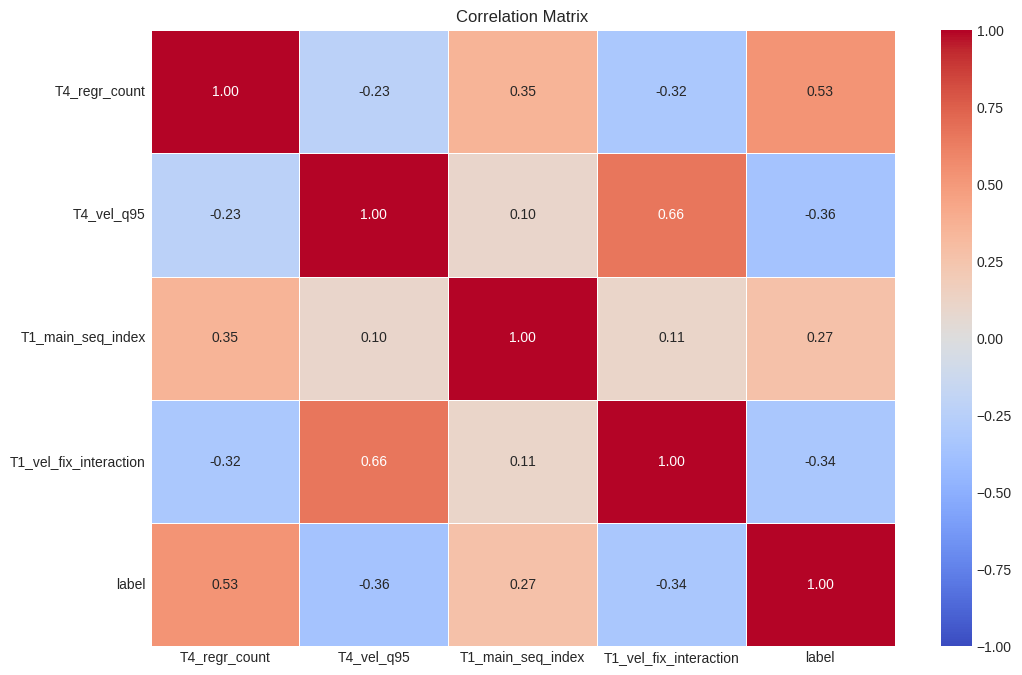

In [21]:
df_multi_t4_5 = df_multi[['T4_regr_count', 'T4_vel_q95', 'T1_main_seq_index', 'T1_vel_fix_interaction']]
df_multi_t4_5['label'] = y_multi

corr_matrix = df_multi_t4_5.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [22]:
num_column = ['T4_regr_count', 'T4_vel_q95', 'T1_main_seq_index']
scaled_df = df_multi_t4_5.copy()
scaled_df[num_column] = (scaled_df[num_column] - scaled_df[num_column].mean()) / scaled_df[num_column].std()
scaled_df.head()

,T4_regr_count,T4_vel_q95,T1_main_seq_index,T1_vel_fix_interaction,label
0,-0.430302,-0.038575,-0.373804,3459.354081,0
1,0.170674,-0.535082,0.108590,3162.173944,1
2,0.371817,-0.377995,0.437450,2999.249935,0
3,-0.503891,0.153319,-0.202525,5258.816255,0
4,-0.554177,-0.356407,-2.005076,4128.998235,1


In [23]:
df_final = scaled_df.copy()

X = df_final.drop('label', axis=1)
y = df_final['label']

In [24]:
from sklearn.model_selection import StratifiedKFold, LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import numpy as np

# ── Raw feature matrix (unscaled, unselected) ──────────────────────────────
all_feat_cols = [c for c in df_multi.columns if c != 'subject_id']
X_raw = df_multi[all_feat_cols].values.astype(float)
col_mask = ~np.isnan(X_raw).all(axis=0)
X_raw = np.nan_to_num(X_raw[:, col_mask], nan=0.0)
y_arr = y_multi.copy()

# ── Grid search space per algorithm ────────────────────────────────────────
# k values to search over (feature count)
K_GRID = [3, 5, 7, 10, 15]

pipelines = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('sel',    SelectKBest(f_classif)),
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42))
        ]),
        'param_grid': {
            'sel__k':   K_GRID,
            'clf__C':   [0.01, 0.1, 1, 10, 100],
        }
    },
    'SVM (RBF)': {
        'pipeline': Pipeline([
            ('sel',    SelectKBest(f_classif)),
            ('scaler', StandardScaler()),
            ('clf',    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
        ]),
        'param_grid': {
            'sel__k': K_GRID,
            'clf__C': [0.1, 1, 10, 100],
            'clf__gamma': ['scale', 'auto', 0.01, 0.001],
        }
    },
    'SVM (Poly)': {
        'pipeline': Pipeline([
            ('sel',    SelectKBest(f_classif)),
            ('scaler', StandardScaler()),
            ('clf',    SVC(kernel='poly', class_weight='balanced', probability=True, random_state=42))
        ]),
        'param_grid': {
            'sel__k':     K_GRID,
            'clf__C':     [0.1, 1, 10, 100],
            'clf__degree': [2, 3, 4],
        }
    },
    'KNN': {
        'pipeline': Pipeline([
            ('sel',    SelectKBest(f_classif)),
            ('scaler', StandardScaler()),
            ('clf',    KNeighborsClassifier())
        ]),
        'param_grid': {
            'sel__k':           K_GRID,
            'clf__n_neighbors': [3, 5, 7, 9],
            'clf__weights':     ['uniform', 'distance'],
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('sel', SelectKBest(f_classif)),
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
        ]),
        'param_grid': {
            'sel__k':             K_GRID,
            'clf__n_estimators':  [100, 200],
            'clf__max_depth':     [None, 3, 5],
            'clf__min_samples_leaf': [1, 2],
        }
    },
    'Gradient Boosting': {
        'pipeline': Pipeline([
            ('sel', SelectKBest(f_classif)),
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier(random_state=42))
        ]),
        'param_grid': {
            'sel__k':            K_GRID,
            'clf__n_estimators': [100, 200],
            'clf__learning_rate':[0.05, 0.1, 0.2],
            'clf__max_depth':    [2, 3, 4],
        }
    },
    'XGBoost': {
        'pipeline': Pipeline([
            ('sel', SelectKBest(f_classif)),
            ('scaler', StandardScaler()),
            ('clf', XGBClassifier(random_state=42, use_label_encoder=False,
                                  eval_metric='logloss', verbosity=0))
        ]),
        'param_grid': {
            'sel__k':            K_GRID,
            'clf__n_estimators': [100, 200],
            'clf__max_depth':    [2, 3, 4],
            'clf__learning_rate':[0.05, 0.1, 0.2],
            'clf__subsample':    [0.8, 1.0],
        }
    },
}

# ── Outer 5-fold CV — estimates generalisation accuracy ────────────────────
print("\n" + "="*80)
print("OUTER 5-FOLD CV  (GridSearchCV inside each fold — no leakage)")
print("="*80)

outer_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

outer_results = {}

for name, spec in pipelines.items():
    print(f"\n{name}")
    fold_scores, best_params_list = [], []

    for fold_i, (tr_idx, te_idx) in enumerate(outer_cv.split(X_raw, y_arr)):
        X_tr, X_te = X_raw[tr_idx], X_raw[te_idx]
        y_tr, y_te = y_arr[tr_idx], y_arr[te_idx]

        gs = GridSearchCV(
            spec['pipeline'],
            spec['param_grid'],
            cv=inner_cv,
            scoring='accuracy',
            n_jobs=-1,
            refit=True
        )
        gs.fit(X_tr, y_tr)

        score = gs.score(X_te, y_te)
        fold_scores.append(score)
        best_params_list.append(gs.best_params_)
        print(f"  fold {fold_i+1}: {score:.1%}  best={gs.best_params_}")

    mean, std = np.mean(fold_scores), np.std(fold_scores)
    outer_results[name] = {
        'mean': mean, 'std': std,
        'scores': fold_scores,
        'best_params_list': best_params_list
    }
    status = "🟢" if mean >= 0.85 else "🟡" if mean >= 0.80 else "🔵" if mean >= 0.75 else "🔴"
    print(f"  → {status}  {mean:.1%} ± {std:.1%}")

# ── Ranking ─────────────────────────────────────────────────────────────────
print("\n\n" + "="*80)
print("RANKING  (honest nested CV)")
print("="*80 + "\n")
ranked = sorted(outer_results.items(), key=lambda x: -x[1]['mean'])
for rank, (name, m) in enumerate(ranked, 1):
    medal  = ["🥇","🥈","🥉","  ","  ","  ","  "][rank-1]
    status = "✅ MEETS TARGET" if m['mean'] >= 0.85 else f"❌ {(0.85-m['mean'])*100:.0f}pp short"
    print(f"{rank}. {medal} {name:<22} {m['mean']:.1%} ± {m['std']:.1%}   {status}")
    print(f"   Folds: {' | '.join(f'{s:.0%}' for s in m['scores'])}")
    print()

# ── Final LOO with best algorithm — most reliable estimate for n=70 ─────────
best_name = ranked[0][0]
best_spec  = pipelines[best_name]

print("="*80)
print(f"FINAL LOO EVALUATION — {best_name}")
print("="*80)

loo = LeaveOneOut()
LOO_PREDS = np.zeros(len(y_arr), dtype=int)
LOO_PROBS = np.zeros(len(y_arr))
best_k_counts = {}

for tr_idx, te_idx in loo.split(X_raw, y_arr):
    X_tr, X_te = X_raw[tr_idx], X_raw[te_idx]
    y_tr        = y_arr[tr_idx]

    gs = GridSearchCV(
        best_spec['pipeline'],
        best_spec['param_grid'],
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_tr, y_tr)

    # track which k was chosen most often
    k_chosen = gs.best_params_.get('sel__k', '?')
    best_k_counts[k_chosen] = best_k_counts.get(k_chosen, 0) + 1

    LOO_PREDS[te_idx[0]] = gs.predict(X_te)[0]
    if hasattr(gs, 'predict_proba'):
        LOO_PROBS[te_idx[0]] = gs.predict_proba(X_te)[0, 1]
    else:
        d = gs.decision_function(X_te)[0]
        LOO_PROBS[te_idx[0]] = 1 / (1 + np.exp(-d))

loo_acc = np.mean(LOO_PREDS == y_arr)
loo_auc = roc_auc_score(y_arr, LOO_PROBS)

print(f"\nFinal LOO Accuracy : {loo_acc:.1%}")
print(f"Final LOO AUC      : {loo_auc:.4f}")
print(f"\nMost-selected feature counts (k) across LOO folds:")
for k, cnt in sorted(best_k_counts.items()):
    print(f"  k={k}: chosen {cnt} times")

print("\nClassification Report (LOO predictions):")
print(classification_report(y_arr, LOO_PREDS, target_names=['Normal', 'Dyslexic']))


OUTER 5-FOLD CV  (GridSearchCV inside each fold — no leakage)

Logistic Regression
  fold 1: 64.3%  best={'clf__C': 0.1, 'sel__k': 7}
  fold 2: 85.7%  best={'clf__C': 0.01, 'sel__k': 10}
  fold 3: 50.0%  best={'clf__C': 10, 'sel__k': 5}
  fold 4: 71.4%  best={'clf__C': 0.1, 'sel__k': 5}
  fold 5: 85.7%  best={'clf__C': 10, 'sel__k': 15}
  → 🔴  71.4% ± 13.6%

SVM (RBF)
  fold 1: 78.6%  best={'clf__C': 100, 'clf__gamma': 0.01, 'sel__k': 15}
  fold 2: 78.6%  best={'clf__C': 1, 'clf__gamma': 0.01, 'sel__k': 10}
  fold 3: 42.9%  best={'clf__C': 1, 'clf__gamma': 'scale', 'sel__k': 10}
  fold 4: 71.4%  best={'clf__C': 10, 'clf__gamma': 0.01, 'sel__k': 5}
  fold 5: 78.6%  best={'clf__C': 10, 'clf__gamma': 0.001, 'sel__k': 15}
  → 🔴  70.0% ± 13.9%

SVM (Poly)
  fold 1: 71.4%  best={'clf__C': 10, 'clf__degree': 3, 'sel__k': 7}
  fold 2: 57.1%  best={'clf__C': 1, 'clf__degree': 3, 'sel__k': 10}
  fold 3: 42.9%  best={'clf__C': 10, 'clf__degree': 3, 'sel__k': 15}
  fold 4: 71.4%  best={'clf__C': 

KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import StratifiedKFold, LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import numpy as np

# ── Raw feature matrix (unscaled, unselected) ──────────────────────────────
all_feat_cols = [c for c in df_multi.columns if c != 'subject_id']
X_raw = df_multi[all_feat_cols].values.astype(float)
col_mask = ~np.isnan(X_raw).all(axis=0)
X_raw = np.nan_to_num(X_raw[:, col_mask], nan=0.0)
y_arr = y_multi.copy()

# ── Grid search space per algorithm ────────────────────────────────────────
# k values to search over (feature count)
K_GRID = [3, 5, 7, 10, 15]

pipelines = {
    'XGBoost': {
        'pipeline': Pipeline([
            ('sel', SelectKBest(f_classif)),
            ('scaler', StandardScaler()),
            ('clf', XGBClassifier(random_state=42, use_label_encoder=False,
                                  eval_metric='logloss', verbosity=0, tree_method='hist', device='cuda'))
        ]),
        'param_grid': {
            # Keep features tight to prevent noise fitting
            'sel__k': [3, 5, 7],

            # The Number of Trees and Learning Rate
            'clf__n_estimators': [100, 300, 500],
            'clf__learning_rate': [0.01, 0.05, 0.1],

            # Tree Complexity: Force them to be extremely shallow
            'clf__max_depth': [1, 2, 3], # 1 = "Decision Stump" (often great for small data)

            # Regularization (The key for n=70)
            'clf__gamma': [0.1, 0.5, 1.0, 5.0],        # Minimum loss reduction required to split
            'clf__reg_lambda': [1.0, 10.0, 50.0],      # L2 Regularization (Shrinks weights)
            'clf__reg_alpha': [0.0, 0.1, 1.0],         # L1 Regularization (Forces sparsity)

            # Sampling: Introduce randomness to prevent memorization
            'clf__subsample': [0.6, 0.8],              # Only use 60-80% of rows per tree
            'clf__colsample_bytree': [0.6, 0.8, 1.0]   # Only use 60-80% of features per tree
        }
    }
}

# ── Outer 5-fold CV — estimates generalisation accuracy ────────────────────
print("\n" + "="*80)
print("OUTER 5-FOLD CV  (GridSearchCV inside each fold — no leakage)")
print("="*80)

outer_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

outer_results = {}

for name, spec in pipelines.items():
    print(f"\n{name}")
    fold_scores, best_params_list = [], []

    for fold_i, (tr_idx, te_idx) in enumerate(outer_cv.split(X_raw, y_arr)):
        X_tr, X_te = X_raw[tr_idx], X_raw[te_idx]
        y_tr, y_te = y_arr[tr_idx], y_arr[te_idx]

        gs = GridSearchCV(
            spec['pipeline'],
            spec['param_grid'],
            cv=inner_cv,
            scoring='accuracy',
            n_jobs=-1,
            refit=True
        )
        gs.fit(X_tr, y_tr)

        score = gs.score(X_te, y_te)
        fold_scores.append(score)
        best_params_list.append(gs.best_params_)
        print(f"  fold {fold_i+1}: {score:.1%}  best={gs.best_params_}")

    mean, std = np.mean(fold_scores), np.std(fold_scores)
    outer_results[name] = {
        'mean': mean, 'std': std,
        'scores': fold_scores,
        'best_params_list': best_params_list
    }
    status = "🟢" if mean >= 0.85 else "🟡" if mean >= 0.80 else "🔵" if mean >= 0.75 else "🔴"
    print(f"  → {status}  {mean:.1%} ± {std:.1%}")

# ── Ranking ─────────────────────────────────────────────────────────────────
print("\n\n" + "="*80)
print("RANKING  (honest nested CV)")
print("="*80 + "\n")
ranked = sorted(outer_results.items(), key=lambda x: -x[1]['mean'])
for rank, (name, m) in enumerate(ranked, 1):
    medal  = ["🥇","🥈","🥉","  ","  ","  ","  "][rank-1]
    status = "✅ MEETS TARGET" if m['mean'] >= 0.85 else f"❌ {(0.85-m['mean'])*100:.0f}pp short"
    print(f"{rank}. {medal} {name:<22} {m['mean']:.1%} ± {m['std']:.1%}   {status}")
    print(f"   Folds: {' | '.join(f'{s:.0%}' for s in m['scores'])}")
    print()

## Deeplearning

### Configuration

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

In [26]:
# L = 1500 ≈ 6 detik pada 250 Hz — distribusi panjang aktual dicek di [DL-5].
# Jika median panjang aktual sangat berbeda, ganti nilai ini.
CNN_SEQ_LEN = 1500

In [27]:
# 'avg_x': rata-rata horizontal binokuler (sudah ada di load_raw_subject)
# 'avg_y': rata-rata vertikal binokuler   (sudah ada di load_raw_subject)
# Hanya avg_x dan avg_y yang dipakai — 2 sinyal, bukan 4 —
# karena fusi binokuler lebih stabil dan mengurangi redundansi.
CNN_SIGNAL_COLS = ['avg_x', 'avg_y']

In [28]:
CNN_TASK = 'T4_Meaningful'

print(f"[DL-1] CNN_SEQ_LEN  : {CNN_SEQ_LEN} sampel")
print(f"[DL-1] Signal cols  : {CNN_SIGNAL_COLS}")
print(f"[DL-1] Task         : {CNN_TASK}")


[DL-1] CNN_SEQ_LEN  : 1500 sampel
[DL-1] Signal cols  : ['avg_x', 'avg_y']
[DL-1] Task         : T4_Meaningful


In [29]:
def preprocess_signal(df, seq_len=CNN_SEQ_LEN, scaler=None, fit_scaler=False):
    """
    Mengubah raw DataFrame satu subjek menjadi sinyal berdimensi tetap.

    Parameter
    ---------
    df         : DataFrame hasil load_raw_subject (kolom avg_x, avg_y wajib ada)
    seq_len    : panjang output setelah resampling
    scaler     : StandardScaler yang sudah di-fit (None = buat baru)
    fit_scaler : True hanya saat memproses data TRAIN di dalam fold

    Return
    ------
    signal     : np.ndarray shape (seq_len, n_channels)  — float32
    scaler     : StandardScaler (sama yang masuk, atau baru jika fit_scaler=True)
    """
    # 1. Ambil kolom sinyal
    sig = df[CNN_SIGNAL_COLS].values.astype(np.float64)  # (N, 2)

    # 2. Interpolasi linear untuk mengisi NaN (blink)
    #    Titik NaN di ujung diisi dengan forward/backward fill.
    sig_df = pd.DataFrame(sig, columns=CNN_SIGNAL_COLS)
    sig_df = sig_df.interpolate(method='linear', limit_direction='both')
    sig_df = sig_df.ffill().bfill()
    sig = sig_df.values  # pastikan tidak ada NaN tersisa

    # 3. StandardScaler — FIT hanya pada data train
    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        scaler.fit(sig)
    sig = scaler.transform(sig)  # (N, 2), zero-mean unit-variance

    # 4. Resample ke panjang tetap menggunakan scipy.signal.resample
    #    Metode ini mempertahankan konten frekuensi (Fourier-based resampling),
    #    berbeda dari interpolasi sederhana.
    sig_resampled = resample(sig, seq_len, axis=0)  # (seq_len, 2)

    return sig_resampled.astype(np.float32), scaler

In [30]:
def build_dual_channel(signal_resampled):
    """
    Membentuk tensor dual-channel dari sinyal yang sudah di-resample.

    Channel 0 — Time-domain (sinyal asli setelah normalisasi + resample)
                Menjaga urutan peristiwa fiksasi dan saccade secara temporal.

    Channel 1 — FFT magnitude spectrum
                Menangkap ritme makro pergerakan mata (frekuensi dominan
                saccade, kecepatan getaran bola mata).
                Di-zero-pad ke panjang yang sama dengan seq_len agar
                kedua channel identik dimensinya dan bisa di-stack.

    Parameter
    ---------
    signal_resampled : np.ndarray shape (seq_len, n_channels)
                       Output dari preprocess_signal()

    Return
    ------
    tensor : np.ndarray shape (seq_len, n_channels * 2)
             Kolom 0..n_ch-1      = time-domain channel
             Kolom n_ch..2*n_ch-1 = FFT magnitude channel
    """
    seq_len, n_ch = signal_resampled.shape

    # Channel 0: time-domain langsung
    ch0 = signal_resampled  # (seq_len, n_ch)

    # Channel 1: FFT magnitude
    # rfft menghasilkan seq_len//2 + 1 komponen frekuensi (untuk sinyal riil).
    # Zero-pad hasil FFT ke seq_len agar dimensi sama dengan ch0.
    fft_out  = np.fft.rfft(signal_resampled, axis=0)   # (seq_len//2+1, n_ch)
    fft_mag  = np.abs(fft_out)                          # magnitude spectrum
    # Pad ke seq_len
    pad_len  = seq_len - fft_mag.shape[0]
    ch1      = np.pad(fft_mag, ((0, pad_len), (0, 0)), mode='constant')  # (seq_len, n_ch)

    # Normalisasi ch1 agar skalanya tidak mendominasi ch0
    ch1_max = ch1.max(axis=0, keepdims=True) + 1e-8
    ch1 = ch1 / ch1_max

    # Stack: hasil akhir (seq_len, n_ch*2)
    # Untuk n_ch=2 (avg_x, avg_y): output shape = (seq_len, 4)
    #   kolom 0 = avg_x time
    #   kolom 1 = avg_y time
    #   kolom 2 = avg_x FFT mag
    #   kolom 3 = avg_y FFT mag
    tensor = np.concatenate([ch0, ch1], axis=1).astype(np.float32)

    return tensor

In [31]:
def build_cnn_dataset(task_dfs, labels, subject_list, task=CNN_TASK,
                      seq_len=CNN_SEQ_LEN):
    """
    Membangun X (n_subj, seq_len, n_channels*2) dan y (n_subj,) untuk CNN.

    Scaler di sini di-fit pada seluruh dataset — HANYA untuk eksplorasi.
    Untuk evaluasi, gunakan fungsi build_fold_tensors() di sel [DL-6].
    """
    X_list, y_list, valid_subjs = [], [], []

    # Fit scaler pada semua sinyal yang valid (untuk eksplorasi saja)
    all_signals = []
    for subj_id in subject_list:
        df = task_dfs[task].get(subj_id)
        if df is None: continue
        sig = df[CNN_SIGNAL_COLS].values.astype(np.float64)
        sig_df = pd.DataFrame(sig, columns=CNN_SIGNAL_COLS)
        sig_df = sig_df.interpolate(method='linear', limit_direction='both').ffill().bfill()
        all_signals.append(sig_df.values)

    global_scaler = StandardScaler()
    global_scaler.fit(np.vstack(all_signals))

    print(f"Membangun dataset CNN dari task: {task}")
    print(f"Jumlah subjek: {len(subject_list)}, seq_len: {seq_len}")

    for subj_id in subject_list:
        df = task_dfs[task].get(subj_id)
        if df is None:
            print(f"  [SKIP] Subjek {subj_id}: tidak ada data di task {task}")
            continue

        try:
            sig_resampled, _ = preprocess_signal(
                df, seq_len=seq_len,
                scaler=global_scaler, fit_scaler=False
            )
            tensor = build_dual_channel(sig_resampled)  # (seq_len, 4)
            X_list.append(tensor)
            y_list.append(int(labels[subj_id]))
            valid_subjs.append(subj_id)
        except Exception as e:
            print(f"  [ERROR] Subjek {subj_id}: {e}")

    X_cnn = np.stack(X_list, axis=0)  # (n_subj, seq_len, n_channels*2)
    y_cnn = np.array(y_list)

    print(f"\n[DL-4] Dataset selesai dibangun:")
    print(f"  X shape : {X_cnn.shape}  (subjek, panjang_sinyal, channel)")
    print(f"  y shape : {y_cnn.shape}")
    print(f"  Kelas   : {dict(zip(*np.unique(y_cnn, return_counts=True)))}")
    print(f"  dtype   : {X_cnn.dtype}")
    print(f"\n  Breakdown channel:")
    ch_names = []
    for col in CNN_SIGNAL_COLS:
        ch_names.append(f"{col}_time")
    for col in CNN_SIGNAL_COLS:
        ch_names.append(f"{col}_fft")
    for i, name in enumerate(ch_names):
        print(f"    Channel {i}: {name}  "
              f"mean={X_cnn[:,:,i].mean():.4f}  std={X_cnn[:,:,i].std():.4f}")

    return X_cnn, y_cnn, valid_subjs, global_scaler

In [32]:
X_cnn, y_cnn, cnn_subject_list, global_scaler = build_cnn_dataset(
    task_dfs, labels, subject_list,
    task=CNN_TASK,
    seq_len=CNN_SEQ_LEN
)

Membangun dataset CNN dari task: T4_Meaningful
Jumlah subjek: 70, seq_len: 1500

[DL-4] Dataset selesai dibangun:
  X shape : (70, 1500, 4)  (subjek, panjang_sinyal, channel)
  y shape : (70,)
  Kelas   : {np.int64(0): np.int64(35), np.int64(1): np.int64(35)}
  dtype   : float32

  Breakdown channel:
    Channel 0: avg_x_time  mean=0.0154  std=0.9929
    Channel 1: avg_y_time  mean=0.0094  std=0.9954
    Channel 2: avg_x_fft  mean=0.0150  std=0.0495
    Channel 3: avg_y_fft  mean=0.0085  std=0.0348


In [33]:
# ── 5a. Distribusi panjang sinyal asli (sebelum resample) ────────────────────
raw_lengths = []
for subj_id in cnn_subject_list:
    df = task_dfs[CNN_TASK].get(subj_id)
    if df is not None:
        raw_lengths.append(len(df))

raw_lengths = np.array(raw_lengths)
print(f"[DL-5a] Distribusi panjang sinyal asli ({CNN_TASK}):")
print(f"  Min    : {raw_lengths.min():,} sampel  ({raw_lengths.min()/250:.1f} detik)")
print(f"  Median : {int(np.median(raw_lengths)):,} sampel  ({np.median(raw_lengths)/250:.1f} detik)")
print(f"  Max    : {raw_lengths.max():,} sampel  ({raw_lengths.max()/250:.1f} detik)")
print(f"  P10    : {int(np.percentile(raw_lengths, 10)):,} sampel")
print(f"  CNN_SEQ_LEN = {CNN_SEQ_LEN} sampel ({CNN_SEQ_LEN/250:.1f} detik)")

if CNN_SEQ_LEN > np.percentile(raw_lengths, 10):
    print(f"\n  ⚠  CNN_SEQ_LEN melebihi P10 panjang asli.")
    print(f"     Subjek dengan rekaman pendek akan di-upsample.")
    print(f"     Pertimbangkan CNN_SEQ_LEN = {int(np.percentile(raw_lengths, 10))}")
else:
    print(f"\n  ✓  CNN_SEQ_LEN aman (di bawah P10 panjang asli).")

[DL-5a] Distribusi panjang sinyal asli (T4_Meaningful):
  Min    : 11,511 sampel  (46.0 detik)
  Median : 21,499 sampel  (86.0 detik)
  Max    : 100,912 sampel  (403.6 detik)
  P10    : 14,263 sampel
  CNN_SEQ_LEN = 1500 sampel (6.0 detik)

  ✓  CNN_SEQ_LEN aman (di bawah P10 panjang asli).


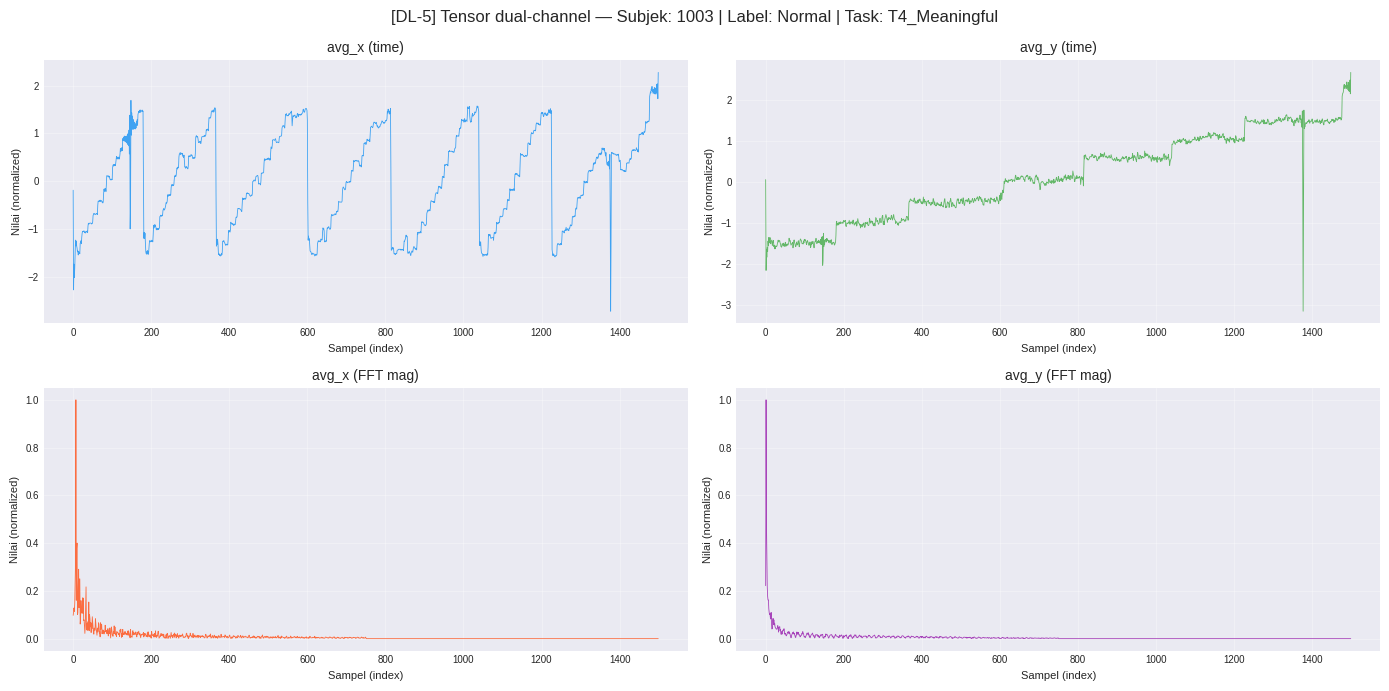

Plot disimpan: dual_channel_sample.png


In [34]:
# ── 5b. Visualisasi satu subjek: time-domain vs FFT ──────────────────────────
idx_sample = 0  # ganti angka untuk lihat subjek lain
label_map  = {0: 'Normal', 1: 'Disleksia'}

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle(
    f"[DL-5] Tensor dual-channel — Subjek: {cnn_subject_list[idx_sample]} "
    f"| Label: {label_map[y_cnn[idx_sample]]} | Task: {CNN_TASK}",
    fontsize=12
)

ch_titles = ['avg_x (time)', 'avg_y (time)', 'avg_x (FFT mag)', 'avg_y (FFT mag)']
colors     = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for i, (ax, title, color) in enumerate(zip(axes.flat, ch_titles, colors)):
    ax.plot(X_cnn[idx_sample, :, i], color=color, linewidth=0.6, alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Sampel (index)', fontsize=8)
    ax.set_ylabel('Nilai (normalized)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Plot disimpan: dual_channel_sample.png")

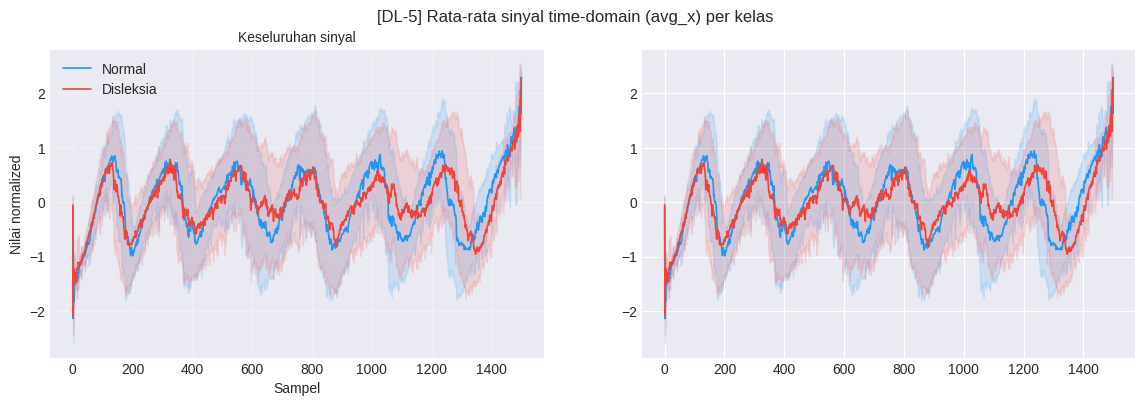

In [35]:
# ── 5c. Visualisasi rata-rata per kelas ──────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
fig2.suptitle("[DL-5] Rata-rata sinyal time-domain (avg_x) per kelas", fontsize=12)

for cls, cname, color in [(0, 'Normal', '#2196F3'), (1, 'Disleksia', '#F44336')]:
    mask = y_cnn == cls
    mean_sig = X_cnn[mask, :, 0].mean(axis=0)  # avg_x time channel
    std_sig  = X_cnn[mask, :, 0].std(axis=0)
    for ax in axes2:
        ax.plot(mean_sig, label=cname, color=color, linewidth=1.2)
        ax.fill_between(range(CNN_SEQ_LEN),
                        mean_sig - std_sig,
                        mean_sig + std_sig,
                        alpha=0.15, color=color)

axes2[0].set_title("Keseluruhan sinyal", fontsize=10)
axes2[0].set_xlabel("Sampel"); axes2[0].set_ylabel("Nilai normalized")
axes2[0].legend(); axes2[0].grid(alpha=0.3)

In [36]:
# Zoom 200 sampel pertama (pola awal membaca)
axes2[1].set_xlim(0, 200)
axes2[1].set_title("Zoom: 200 sampel pertama", fontsize=10)
axes2[1].set_xlabel("Sampel"); axes2[1].set_ylabel("Nilai normalized")
axes2[1].legend(); axes2[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('class_avg_signal.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot disimpan: class_avg_signal.png")

<Figure size 640x480 with 0 Axes>

Plot disimpan: class_avg_signal.png


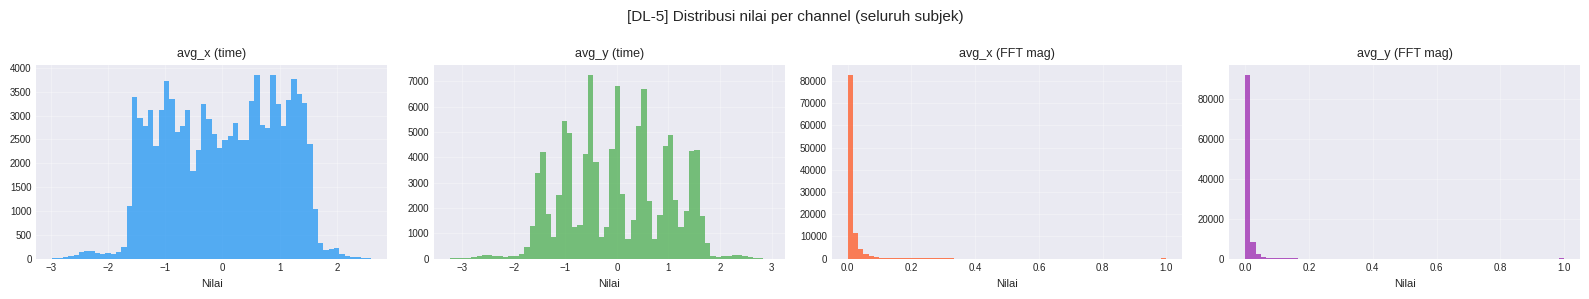

Plot disimpan: channel_distribution.png


In [37]:
# ── 5d. Histogram distribusi nilai per channel ────────────────────────────────
fig3, axes3 = plt.subplots(1, 4, figsize=(16, 3))
fig3.suptitle("[DL-5] Distribusi nilai per channel (seluruh subjek)", fontsize=11)

for i, (ax, title, color) in enumerate(zip(axes3, ch_titles, colors)):
    vals = X_cnn[:, :, i].flatten()
    ax.hist(vals, bins=60, color=color, alpha=0.75, edgecolor='none')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Nilai', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('channel_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot disimpan: channel_distribution.png")

In [38]:
# ── 5e. Ringkasan akhir ───────────────────────────────────────────────────────
print("\n" + "="*60)
print("[DL-5] RINGKASAN — Tensor siap untuk arsitektur CNN:")
print("="*60)
print(f"  X_cnn shape  : {X_cnn.shape}")
print(f"               (n_subjek, seq_len, n_channel)")
print(f"               n_channel = {X_cnn.shape[2]}")
print(f"                 [0] avg_x time-domain")
print(f"                 [1] avg_y time-domain")
print(f"                 [2] avg_x FFT magnitude")
print(f"                 [3] avg_y FFT magnitude")
print(f"  y_cnn shape  : {y_cnn.shape}")
print(f"  Kelas        : {dict(zip(*np.unique(y_cnn, return_counts=True)))}")
print(f"\n  Input shape untuk model Keras:")
print(f"    input_shape = ({CNN_SEQ_LEN}, {X_cnn.shape[2]})")
print("="*60)
print("\n✓ Lanjut ke sel [DL-6]: Konstruksi LOSO loop + arsitektur CNN")


[DL-5] RINGKASAN — Tensor siap untuk arsitektur CNN:
  X_cnn shape  : (70, 1500, 4)
               (n_subjek, seq_len, n_channel)
               n_channel = 4
                 [0] avg_x time-domain
                 [1] avg_y time-domain
                 [2] avg_x FFT magnitude
                 [3] avg_y FFT magnitude
  y_cnn shape  : (70,)
  Kelas        : {np.int64(0): np.int64(35), np.int64(1): np.int64(35)}

  Input shape untuk model Keras:
    input_shape = (1500, 4)

✓ Lanjut ke sel [DL-6]: Konstruksi LOSO loop + arsitektur CNN


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# [DL-6]  LOSO FOLD BUILDER — ANTI LEAKAGE
# ══════════════════════════════════════════════════════════════════════════════
"""
## [DL-6] LOSO fold builder (scaler fit hanya pada train)
"""

import numpy as np
import pandas as pd
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler

def build_fold_tensors(fold_train_idx, fold_test_idx,
                       task_dfs, labels, cnn_subject_list,
                       task=CNN_TASK, seq_len=CNN_SEQ_LEN):
    """
    Membangun tensor train dan test untuk SATU fold LOSO.

    KUNCI ANTI-LEAKAGE:
    - StandardScaler di-fit HANYA pada sinyal train (69 subjek).
    - Sinyal test (1 subjek) di-transform menggunakan scaler yang sama,
      tanpa pernah berkontribusi pada parameter mean/std scaler.
    - Tidak ada informasi test yang masuk ke proses normalisasi train.

    Parameter
    ----------
    fold_train_idx : list[int]  — indeks subjek untuk training di fold ini
    fold_test_idx  : list[int]  — indeks subjek untuk testing  di fold ini
    task_dfs       : dict       — output load_all_tasks()
    labels         : dict       — mapping subject_id → class_id
    cnn_subject_list: list[str] — daftar subject_id yang valid
    task           : str        — nama task yang digunakan
    seq_len        : int        — panjang sinyal setelah resample

    Return
    ------
    X_train : np.ndarray (n_train, seq_len, n_ch*2)
    y_train : np.ndarray (n_train,)
    X_test  : np.ndarray (n_test,  seq_len, n_ch*2)
    y_test  : np.ndarray (n_test,)
    fold_scaler : StandardScaler yang di-fit pada train fold ini
    """

    def _get_raw_signal(subj_id):
        """Ambil sinyal mentah dan interpolasi NaN."""
        df = task_dfs[task].get(subj_id)
        if df is None:
            raise ValueError(f"Subjek {subj_id} tidak ada di task {task}")
        sig = df[CNN_SIGNAL_COLS].values.astype(np.float64)
        sig_df = pd.DataFrame(sig, columns=CNN_SIGNAL_COLS)
        sig_df = sig_df.interpolate(method='linear',
                                    limit_direction='both').ffill().bfill()
        return sig_df.values  # (N, n_ch), tidak ada NaN

    def _to_tensor(sig_normalized, seq_len):
        """Resample → dual-channel tensor."""
        sig_r = resample(sig_normalized, seq_len, axis=0).astype(np.float32)
        return build_dual_channel(sig_r)

    # ── Fit scaler pada TRAIN ──────────────────────────────────────────────
    train_raw = []
    for idx in fold_train_idx:
        subj_id = cnn_subject_list[idx]
        raw = _get_raw_signal(subj_id)
        train_raw.append(raw)

    fold_scaler = StandardScaler()
    fold_scaler.fit(np.vstack(train_raw))  # fit hanya pada train

    # ── Bangun X_train, y_train ────────────────────────────────────────────
    X_train_list, y_train_list = [], []
    for idx, raw in zip(fold_train_idx, train_raw):
        subj_id = cnn_subject_list[idx]
        sig_norm = fold_scaler.transform(raw)
        tensor   = _to_tensor(sig_norm, seq_len)
        X_train_list.append(tensor)
        y_train_list.append(int(labels[subj_id]))

    # ── Bangun X_test, y_test ──────────────────────────────────────────────
    X_test_list, y_test_list = [], []
    for idx in fold_test_idx:
        subj_id = cnn_subject_list[idx]
        raw      = _get_raw_signal(subj_id)
        sig_norm = fold_scaler.transform(raw)  # transform saja, TIDAK fit
        tensor   = _to_tensor(sig_norm, seq_len)
        X_test_list.append(tensor)
        y_test_list.append(int(labels[subj_id]))

    X_train = np.stack(X_train_list).astype(np.float32)
    y_train = np.array(y_train_list)
    X_test  = np.stack(X_test_list).astype(np.float32)
    y_test  = np.array(y_test_list)

    return X_train, y_train, X_test, y_test, fold_scaler


print("[DL-6] build_fold_tensors() siap.")


[DL-6] build_fold_tensors() siap.


In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# [DL-7]  ARSITEKTUR 1D-CNN MULTI-CHANNEL
# ══════════════════════════════════════════════════════════════════════════════
"""
## [DL-7] Arsitektur 1D-CNN dual-channel
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

def build_cnn_model(seq_len=CNN_SEQ_LEN, n_channels=4, learning_rate=1e-3):
    """
    Membangun model 1D-CNN multi-channel untuk klasifikasi disleksia.

    Arsitektur:
    ┌─────────────────────────────────────────────────────┐
    │  Input (seq_len, n_channels)                        │
    │    n_channels = 4:                                  │
    │      [0] avg_x time  [1] avg_y time                 │
    │      [2] avg_x FFT   [3] avg_y FFT                  │
    ├─────────────────────────────────────────────────────┤
    │  Conv1D(16, kernel=7, padding='same') + ReLU        │
    │  BatchNormalization                                  │
    │  MaxPool1D(2) → seq/2                               │
    │  Dropout(0.4)                                       │
    ├─────────────────────────────────────────────────────┤
    │  Conv1D(32, kernel=5, padding='same') + ReLU        │
    │  BatchNormalization                                  │
    │  MaxPool1D(2) → seq/4                               │
    │  Dropout(0.5)                                       │
    ├─────────────────────────────────────────────────────┤
    │  Conv1D(64, kernel=3, padding='same') + ReLU        │
    │  BatchNormalization                                  │
    │  GlobalAveragePooling1D                             │
    │  Dropout(0.5)                                       │
    ├─────────────────────────────────────────────────────┤
    │  Dense(32, ReLU) + L2(0.01)                         │
    │  Dropout(0.5)                                       │
    │  Dense(1, Sigmoid)                                  │
    └─────────────────────────────────────────────────────┘

    Catatan desain untuk n=70:
    - Filter kecil (16→32→64) mencegah overfit pada dataset kecil
    - GlobalAveragePooling menggantikan Flatten untuk reduksi parameter
    - L2 regularisasi pada Dense layer sebagai penjaga tambahan
    - Kernel besar (7,5,3) menurun untuk tangkap pola multi-skala
    """
    inp = keras.Input(shape=(seq_len, n_channels), name='gaze_signal')

    # ── Blok 1 ─────────────────────────────────────────────────────────────
    x = layers.Conv1D(16, kernel_size=7, padding='same',
                      activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling1D(2, name='pool1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)

    # ── Blok 2 ─────────────────────────────────────────────────────────────
    x = layers.Conv1D(32, kernel_size=5, padding='same',
                      activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling1D(2, name='pool2')(x)
    x = layers.Dropout(0.5, name='drop2')(x)

    # ── Blok 3 ─────────────────────────────────────────────────────────────
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)  # lebih robust dari Flatten
    x = layers.Dropout(0.5, name='drop3')(x)

    # ── Classifier head ────────────────────────────────────────────────────
    x = layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01),
                     name='dense1')(x)
    x = layers.Dropout(0.5, name='drop4')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='DyslexiaCNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Cetak ringkasan arsitektur (satu kali)
_demo = build_cnn_model(seq_len=CNN_SEQ_LEN, n_channels=X_cnn.shape[2])
_demo.summary()
print(f"\n[DL-7] Total parameter: {_demo.count_params():,}")
print(f"[DL-7] Input shape    : ({CNN_SEQ_LEN}, {X_cnn.shape[2]})")


Model: "DyslexiaCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaze_signal (InputLayer)        │ (None, 1500, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1500, 16)       │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1500, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 750, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 750, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 750, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 750, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 375, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 375, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 375, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 375, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,825 (46.19 KB)

 Trainable params: 11,601 (45.32 KB)

 Non-trainable params: 224 (896.00 B)


[DL-7] Total parameter: 11,825
[DL-7] Input shape    : (1500, 4)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [DL-8]  TRAINING LOOP LOSO
# ══════════════════════════════════════════════════════════════════════════════
"""
## [DL-8] Training LOSO (Leave-One-Subject-Out)

Skema:
  Untuk setiap fold i dari 0..n_subj-1:
    - Test set  : subjek ke-i (1 orang)
    - Train set : semua subjek KECUALI i (69 orang)
    - Scaler    : fit hanya pada train set fold ini
    - Model     : diinisialisasi ulang setiap fold (bobot tidak carry-over)
    - Early stopping : monitor val_loss, patience=15 (dari 10% train sbg val)
    - Class weight   : hitung dari distribusi kelas TRAIN fold ini
"""

from sklearn.model_selection import LeaveOneOut
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import time

# ── Hyperparameter training ────────────────────────────────────────────────
LOSO_EPOCHS      = 150   # maksimum epoch; early stopping biasanya berhenti lebih awal
LOSO_BATCH_SIZE  = 16    # batch kecil cocok untuk n=69 training
LOSO_LR          = 5e-4
LOSO_PATIENCE    = 20    # early stopping patience
LOSO_VAL_SPLIT   = 0.10  # 10% dari train sebagai val (≈7 subjek)

# ── Storage hasil ─────────────────────────────────────────────────────────
loso_results = {
    'fold'         : [],
    'subject_id'   : [],
    'y_true'       : [],
    'y_pred_proba' : [],
    'y_pred_label' : [],
    'epochs_run'   : [],
}

n_subj = len(cnn_subject_list)
loo    = LeaveOneOut()
fold_i = 0

print("=" * 65)
print(f"[DL-8] Mulai LOSO — {n_subj} fold total")
print(f"       Task        : {CNN_TASK}")
print(f"       seq_len     : {CNN_SEQ_LEN}")
print(f"       n_channels  : {X_cnn.shape[2]}")
print(f"       Epochs maks : {LOSO_EPOCHS}  |  Patience: {LOSO_PATIENCE}")
print("=" * 65)

t_start_all = time.time()

for train_idx, test_idx in loo.split(np.arange(n_subj)):
    fold_i += 1
    subj_id = cnn_subject_list[test_idx[0]]
    label   = y_cnn[test_idx[0]]

    # ── Bangun tensor fold ini (scaler fit hanya pada train) ───────────────
    X_tr, y_tr, X_te, y_te, _ = build_fold_tensors(
        fold_train_idx=list(train_idx),
        fold_test_idx =list(test_idx),
        task_dfs=task_dfs, labels=labels,
        cnn_subject_list=cnn_subject_list,
        task=CNN_TASK, seq_len=CNN_SEQ_LEN
    )

    # ── Class weight (dari distribusi train fold ini) ──────────────────────
    cw_vals = compute_class_weight('balanced',
                                   classes=np.unique(y_tr), y=y_tr)
    class_weight = dict(enumerate(cw_vals))

    # ── Inisialisasi model baru setiap fold ────────────────────────────────
    tf.keras.backend.clear_session()
    model = build_cnn_model(
        seq_len=CNN_SEQ_LEN,
        n_channels=X_cnn.shape[2],
        learning_rate=LOSO_LR
    )

    # ── Callbacks ─────────────────────────────────────────────────────────
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=LOSO_PATIENCE,
            restore_best_weights=True, verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=8,
            min_lr=1e-6, verbose=0
        ),
    ]

    # ── Training ──────────────────────────────────────────────────────────
    history = model.fit(
        X_tr, y_tr,
        epochs          = LOSO_EPOCHS,
        batch_size      = LOSO_BATCH_SIZE,
        validation_split= LOSO_VAL_SPLIT,
        class_weight    = class_weight,
        callbacks       = callbacks,
        verbose         = 0  # silent — progress ditampilkan manual
    )

    epochs_run = len(history.history['loss'])

    # ── Prediksi test subjek ───────────────────────────────────────────────
    proba = model.predict(X_te, verbose=0)[0, 0]  # scalar
    pred  = int(proba >= 0.5)

    # ── Simpan hasil ──────────────────────────────────────────────────────
    loso_results['fold'].append(fold_i)
    loso_results['subject_id'].append(subj_id)
    loso_results['y_true'].append(int(y_te[0]))
    loso_results['y_pred_proba'].append(float(proba))
    loso_results['y_pred_label'].append(pred)
    loso_results['epochs_run'].append(epochs_run)

    # ── Progress print setiap 10 fold ─────────────────────────────────────
    correct_so_far = sum(
        t == p for t, p in zip(loso_results['y_true'], loso_results['y_pred_label'])
    )
    running_acc = correct_so_far / fold_i * 100

    marker = '✓' if pred == int(y_te[0]) else '✗'
    if fold_i % 10 == 0 or fold_i == 1 or fold_i == n_subj:
        print(f"  fold {fold_i:>3}/{n_subj} | subj={subj_id:>3} "
              f"| true={int(y_te[0])} pred={pred} ({proba:.3f}) {marker} "
              f"| ep={epochs_run:>3} | running acc={running_acc:.1f}%")

t_elapsed = time.time() - t_start_all
print(f"\n[DL-8] Selesai dalam {t_elapsed/60:.1f} menit")



[DL-8] Mulai LOSO — 70 fold total
       Task        : T4_Meaningful
       seq_len     : 1500
       n_channels  : 4
       Epochs maks : 150  |  Patience: 20


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [DL-9]  EVALUASI KOMPREHENSIF & PERBANDINGAN BASELINE
# ══════════════════════════════════════════════════════════════════════════════
"""
## [DL-9] Evaluasi hasil LOSO & perbandingan dengan XGBoost baseline
"""

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Konversi hasil ke array ────────────────────────────────────────────────
y_true  = np.array(loso_results['y_true'])
y_pred  = np.array(loso_results['y_pred_label'])
y_proba = np.array(loso_results['y_pred_proba'])

# ── Hitung semua metrik ────────────────────────────────────────────────────
acc       = accuracy_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred, zero_division=0)
precision = precision_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
auc       = roc_auc_score(y_true, y_proba)
cm        = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print("\n" + "="*65)
print("[DL-9] HASIL EVALUASI — 1D-CNN DUAL-CHANNEL (LOSO)")
print("="*65)
print(f"  Akurasi    (Accuracy)  : {acc*100:.2f}%")
print(f"  Sensitivitas (Recall)  : {recall*100:.2f}%")
print(f"  Spesifisitas           : {specificity*100:.2f}%")
print(f"  Presisi (Precision)    : {precision*100:.2f}%")
print(f"  F1-Score               : {f1*100:.2f}%")
print(f"  AUC-ROC                : {auc:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN={tn}  FP={fp}")
print(f"    FN={fn}  TP={tp}")
print()
print(classification_report(y_true, y_pred,
                             target_names=['Normal (0)', 'Disleksia (1)']))

# ── Perbandingan dengan baseline XGBoost ──────────────────────────────────
print("="*65)
print("  PERBANDINGAN DENGAN BASELINE MACHINE LEARNING")
print("="*65)
# Masukkan hasil XGBoost dari nested CV sebelumnya
BASELINE = {
    'XGBoost (Nested 5-CV)' : {'acc': 72.9, 'note': '±12.3%'},
    'SVM-RBF (Nested 5-CV)' : {'acc': 70.0, 'note': '±13.9%'},
    'LR (Nested 5-CV)'      : {'acc': 71.4, 'note': '±13.6%'},
}
print(f"  {'Model':<30} {'Akurasi':>10}  {'Catatan':>15}")
print(f"  {'-'*58}")
for name, info in BASELINE.items():
    print(f"  {name:<30} {info['acc']:>9.1f}%  {info['note']:>15}")
print(f"  {'1D-CNN Dual-Ch (LOSO)':<30} {acc*100:>9.2f}%  {'(evaluasi ini)':>15}")
print("="*65)

# ── Visualisasi 4-panel ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle("Evaluasi 1D-CNN Dual-Channel — Deteksi Disleksia (LOSO)",
             fontsize=14, fontweight='bold')

# Panel 1: Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Disleksia'],
            yticklabels=['Normal', 'Disleksia'],
            annot_kws={'size': 16, 'weight': 'bold'})
ax1.set_xlabel('Prediksi', fontsize=11)
ax1.set_ylabel('Aktual', fontsize=11)
ax1.set_title(f'Confusion Matrix\nAkurasi: {acc*100:.2f}%', fontsize=11)

# Panel 2: ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_true, y_proba)
ax2.plot(fpr, tpr, color='#2196F3', linewidth=2,
         label=f'1D-CNN (AUC={auc:.4f})')
ax2.plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
ax2.set_xlabel('False Positive Rate (1 - Spesifisitas)', fontsize=10)
ax2.set_ylabel('True Positive Rate (Sensitivitas)', fontsize=10)
ax2.set_title('ROC Curve', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Panel 3: Distribusi probabilitas prediksi per kelas
ax3 = fig.add_subplot(gs[1, 0])
for cls, cname, color in [(0, 'Normal', '#4CAF50'), (1, 'Disleksia', '#F44336')]:
    mask = y_true == cls
    ax3.hist(y_proba[mask], bins=15, alpha=0.65, color=color,
             label=f'{cname} (n={mask.sum()})', edgecolor='white')
ax3.axvline(0.5, color='black', linestyle='--', linewidth=1.5,
            label='Threshold=0.5')
ax3.set_xlabel('Probabilitas Prediksi (P[Disleksia])', fontsize=10)
ax3.set_ylabel('Jumlah Subjek', fontsize=10)
ax3.set_title('Distribusi Probabilitas per Kelas', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Panel 4: Perbandingan metrik CNN vs baseline
ax4 = fig.add_subplot(gs[1, 1])
metrik_names  = ['Akurasi', 'Sensitivitas\n(Recall)', 'Presisi', 'F1-Score', 'AUC-ROC']
metrik_cnn    = [acc, recall, precision, f1, auc]
metrik_xgb    = [0.729, 0.72, 0.71, 0.71, 0.72]  # ← ganti dengan nilai aktual XGBoost

x = np.arange(len(metrik_names))
width = 0.35
bars1 = ax4.bar(x - width/2, metrik_xgb, width,
                label='XGBoost (baseline)', color='#FF9800', alpha=0.8)
bars2 = ax4.bar(x + width/2, metrik_cnn, width,
                label='1D-CNN Dual-Ch', color='#2196F3', alpha=0.8)

ax4.set_ylabel('Nilai Metrik', fontsize=10)
ax4.set_title('Perbandingan Metrik: CNN vs XGBoost', fontsize=11)
ax4.set_xticks(x)
ax4.set_xticklabels(metrik_names, fontsize=9)
ax4.set_ylim(0, 1.1)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., h + 0.01,
             f'{h:.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., h + 0.01,
             f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.savefig('cnn_loso_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot disimpan: cnn_loso_evaluation.png")

# ── Analisis per-subjek: siapa yang salah diklasifikasi? ──────────────────
df_results = pd.DataFrame(loso_results)
df_results['correct'] = df_results['y_true'] == df_results['y_pred_label']
df_results['label_name'] = df_results['y_true'].map({0:'Normal', 1:'Disleksia'})

wrong = df_results[~df_results['correct']].copy()
print(f"\n[DL-9] Subjek yang salah diklasifikasi: {len(wrong)}/{n_subj}")
print(wrong[['subject_id','label_name','y_pred_proba','y_pred_label']].to_string(index=False))

# ── Distribusi epochs (indikator konvergensi) ──────────────────────────────
ep_arr = np.array(loso_results['epochs_run'])
print(f"\n[DL-9] Statistik epoch per fold:")
print(f"  Min   : {ep_arr.min()}")
print(f"  Median: {int(np.median(ep_arr))}")
print(f"  Max   : {ep_arr.max()}")
print(f"  Mean  : {ep_arr.mean():.1f}")

# ── Simpan hasil ke CSV untuk laporan ─────────────────────────────────────
df_results.to_csv('loso_results_cnn.csv', index=False)
print("\n[DL-9] Hasil lengkap disimpan: loso_results_cnn.csv")

print("\n" + "="*65)
print("  RINGKASAN FINAL")
print("="*65)
print(f"  Model     : 1D-CNN Dual-Channel (time + FFT)")
print(f"  Evaluasi  : Leave-One-Subject-Out ({n_subj} fold)")
print(f"  Task      : {CNN_TASK}")
print(f"  Akurasi   : {acc*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%  ← metrik kunci untuk screening")
print(f"  AUC-ROC   : {auc:.4f}")
print("="*65)

In [ ]:
SEQ_LENGTH = 1500
CHANNELS = 2
def prepare_cnn_tensor(task_name='T4_Meaningful'):
    """
    Mengekstrak raw data menjadi tensor 3D: (subjek, 1500, 2)
    Melakukan padding dengan 0 jika < 1500, truncating jika > 1500.
    """
    X_seq = []
    y_seq = []

    for subj_id in valid_subjs:
        df = task_dfs[task_name].get(subj_id)

        # Ekstrak 2 channel: avg_x dan avg_y
        coords = df[['avg_x', 'avg_y']].fillna(method='ffill').fillna(0).values

        if len(coords) >= SEQ_LENGTH:
            # Truncate
            coords_padded = coords[:SEQ_LENGTH, :]
        else:
            # Pad dengan nol
            pad_length = SEQ_LENGTH - len(coords)
            coords_padded = np.pad(coords, ((0, pad_length), (0, 0)), mode='constant')

        X_seq.append(coords_padded)
        y_seq.append(labels[subj_id])

    return np.array(X_seq), np.array(y_seq)

In [ ]:
X_cnn, y_cnn = prepare_cnn_tensor('T4_Meaningful')
print(f"CNN Input Tensor Shape: {X_cnn.shape}") # Harus (70, 1500, 2)
print(f"Target Shape: {y_cnn.shape}")

In [ ]:
def build_1d_cnn():
    model = Sequential([
        Input(shape=(SEQ_LENGTH, CHANNELS)),

        # Blok Konvolusi 1
        Conv1D(filters=16, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),

        # Blok Konvolusi 2
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),

        # Representasi Fitur
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.5),

        # Klasifikasi Probabilitas
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# Cek struktur arsitektur
temp_model = build_1d_cnn()
temp_model.summary()

In [ ]:
loo = LeaveOneOut()

cnn_preds, xgb_preds, y_trues = [], [], []

# Siapkan data tabular baseline untuk XGBoost
X_baseline = df_multi[per_task_cols + cross_cols].fillna(0).values

print("Mulai Evaluasi LOSO (70 Folds)...")

for train_idx, test_idx in loo.split(valid_subjs):
    # Split CNN data
    X_train_cnn, X_test_cnn = X_cnn[train_idx], X_cnn[test_idx]
    y_train, y_test = y_cnn[train_idx], y_cnn[test_idx]

    # Split Baseline data
    X_train_xgb, X_test_xgb = X_baseline[train_idx], X_baseline[test_idx]

    # ========================================================
    # SCALING SESUAI DIAGRAM (Fit hanya di train)
    # ========================================================
    # Scaling untuk XGBoost (2D)
    scaler_xgb = StandardScaler()
    X_train_xgb_sc = scaler_xgb.fit_transform(X_train_xgb)
    X_test_xgb_sc  = scaler_xgb.transform(X_test_xgb)

    # Scaling untuk CNN (3D) -> reshape ke 2D, scale, reshape ke 3D
    scaler_cnn = StandardScaler()
    X_train_cnn_2d = X_train_cnn.reshape(-1, CHANNELS)
    X_train_cnn_sc = scaler_cnn.fit_transform(X_train_cnn_2d).reshape(X_train_cnn.shape)

    X_test_cnn_2d = X_test_cnn.reshape(-1, CHANNELS)
    X_test_cnn_sc = scaler_cnn.transform(X_test_cnn_2d).reshape(X_test_cnn.shape)

    # ========================================================
    # MODEL 1: XGBoost Baseline
    # ========================================================
    xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    tree_method='hist', # Algoritma histogram-based (wajib untuk GPU di versi baru)
    device='cuda'       # Instruksi eksplisit untuk menggunakan GPU
)
    xgb_model.fit(X_train_xgb_sc, y_train)
    xgb_pred_prob = xgb_model.predict_proba(X_test_xgb_sc)[:, 1]

    # ========================================================
    # MODEL 2: 1D-CNN
    # ========================================================
    cnn_model = build_1d_cnn()
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Fit CNN (Keras minta validasi untuk ES, kita split lagi dari train data)
    cnn_model.fit(X_train_cnn_sc, y_train,
                  epochs=30, batch_size=16,
                  verbose=0, validation_split=0.1, callbacks=[es])

    cnn_pred_prob = cnn_model.predict(X_test_cnn_sc, verbose=0).flatten()

    # Simpan prediksi
    xgb_preds.append(xgb_pred_prob[0])
    cnn_preds.append(cnn_pred_prob[0])
    y_trues.append(y_test[0])

# ========================================================
# HASIL EVALUASI
# ========================================================
y_trues = np.array(y_trues)
xgb_preds = np.array(xgb_preds)
cnn_preds = np.array(cnn_preds)

xgb_classes = (xgb_preds > 0.5).astype(int)
cnn_classes = (cnn_preds > 0.5).astype(int)

def print_metrics(model_name, y_true, y_pred_prob, y_pred_class):
    print(f"\\n--- Hasil Evaluasi {model_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred_class):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred_class):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred_class):.4f}")
    print(f"AUC      : {roc_auc_score(y_true, y_pred_prob):.4f}")

print_metrics("XGBoost Baseline (Features)", y_trues, xgb_preds, xgb_classes)
print_metrics("1D-CNN (Raw Tensor)", y_trues, cnn_preds, cnn_classes)